# seaborn 学习簿

`seaborn` 是基于 `matplotlib` 的 Python 数据可视化库，专为统计图表设计。它提供了更高级的接口和美观的默认样式，特别适合探索性数据分析和统计可视化。`seaborn` 可以和 `pandas` `polars` 等数据结构紧密集成，处理复杂的数据可视化任务。

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

## 通用方法

### 基本操作

`seaborn` 提供与 `matplotlib` 类似的基本接口，下面的一些基本操作和 `matplotlib` 几乎一样：

- 设置画布大小：`plt.figure(figsize=(width, height))`
  - `figsize`：图形大小，(宽, 高)，单位为英寸

- 设置标题：`plt.title(label)`
  - `label`：图表标题文本

- 显示图形：`plt.show()`

- 创建子图：`plt.subplot(nrows, ncols, index)`
  - `nrows`：子图的行数
  - `ncols`：子图的列数
  - `index`：当前绘制的是第几个子图（从 `1` 开始）

### 主题与风格

#### 全局主题

可以使用 `sns.set_theme()` 方法来设置 `seaborn` 的全局主题风格，可选参数如下：

- 无参数时，使用默认主题
- `context`：上下文参数，可选值有 `'paper'`、`'notebook'`、`'talk'`、`'poster'`，默认为 `'notebook'`
- `style`：样式参数，可选值有 `'darkgrid'`、`'whitegrid'`、`'dark'`、`'white'`、`'ticks'`，默认为 `'darkgrid'`
- `palette`：调色盘参数，可选值有 `'deep'`、`'muted'`、`'bright'`、`'pastel'`、`'dark'`、`'colorblind'`，默认为 `'deep'`
- `font`：字体参数，默认为 `'sans-serif'`
- `font_scale`：字体大小参数，默认为 `1`
- `rc`：可以用 `rcParams` 字典重置 `set_theme` 设置的参数

#### 图表样式

可以使用 `sns.set_style()` 方法来设置图表的样式风格，`seaborn` 提供了5种预设样式，可以快速改变图表的主题。

- `'darkgrid'`：黑色背景带有白色网格，数据点和线条颜色较深，对比度高，适合营造深度感和层次感的图表；
- `'whitegrid'`：以白色为背景，灰色网格线辅助，数据点和线条颜色较浅，风格简洁、清新，适合展示简洁明了的数据关系；
- `'dark'`：整个图表以深色系为主，数据点、线条和背景均为深色，文字和其他元素为对比鲜明的亮色，常用于营造高端、大气的视觉效果；
- `'white'`：与 `'dark'` 风格相反，以白色为背景，所有元素基本都呈现为白色或浅色，适合在简洁、明亮的环境中展示图表；
- `'ticks'`：该风格下坐标轴刻度位置有特殊标记，通常是较长的刻度线或特定的标记样式，突出了坐标轴的位置和刻度，使图表更具参考性。

下面是各风格的样例效果：

Available Seaborn style parameters:
{'axes.facecolor': 'white', 'axes.edgecolor': 'black', 'axes.grid': False, 'axes.axisbelow': 'line', 'axes.labelcolor': 'black', 'figure.facecolor': 'white', 'grid.color': '#b0b0b0', 'grid.linestyle': '-', 'text.color': 'black', 'xtick.color': 'black', 'ytick.color': 'black', 'xtick.direction': 'out', 'ytick.direction': 'out', 'lines.solid_capstyle': <CapStyle.projecting: 'projecting'>, 'patch.edgecolor': 'black', 'patch.force_edgecolor': False, 'image.cmap': 'viridis', 'font.family': ['sans-serif'], 'font.sans-serif': ['DejaVu Sans', 'Bitstream Vera Sans', 'Computer Modern Sans Serif', 'Lucida Grande', 'Verdana', 'Geneva', 'Lucid', 'Arial', 'Helvetica', 'Avant Garde', 'sans-serif'], 'xtick.bottom': True, 'xtick.top': False, 'ytick.left': True, 'ytick.right': False, 'axes.spines.left': True, 'axes.spines.bottom': True, 'axes.spines.right': True, 'axes.spines.top': True}
Predefined Seaborn styles:
['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']


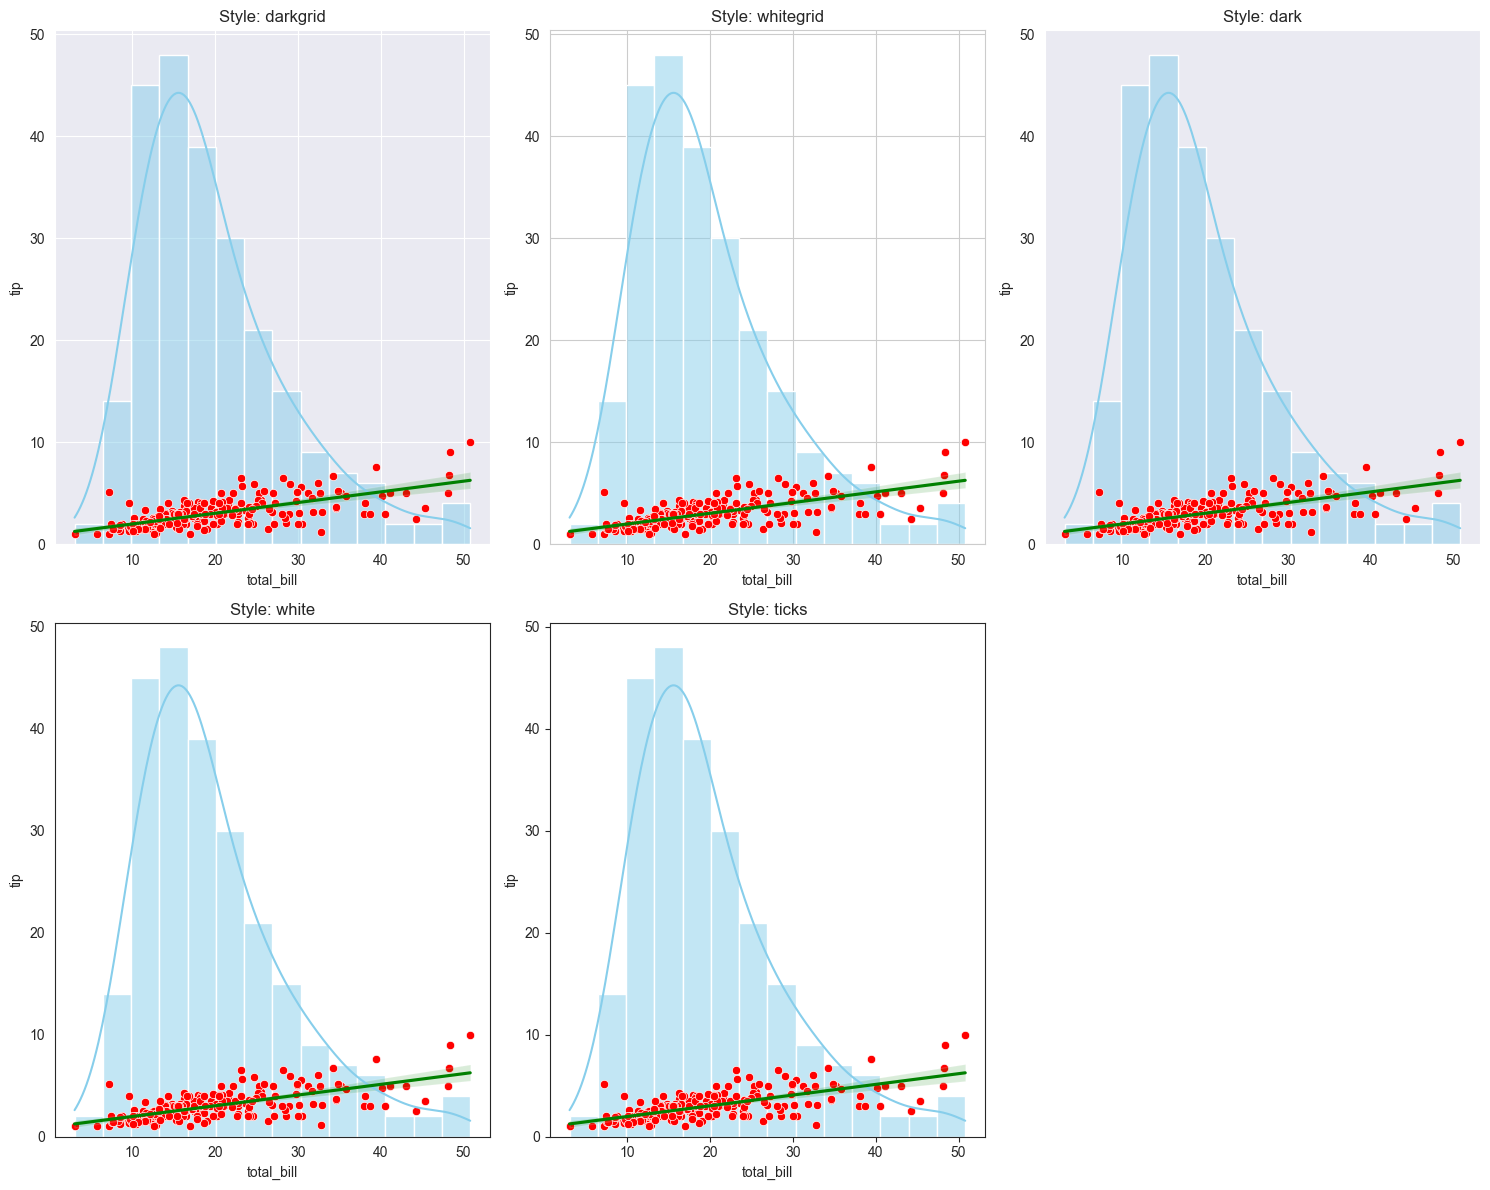

In [2]:
available_styles = sns.axes_style()
print("Available Seaborn style parameters:")
print(available_styles)

predefined_styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
print("Predefined Seaborn styles:")
print(predefined_styles)

data = sns.load_dataset("tips")

plt.figure(figsize=(15, 12))
for i, style in enumerate(predefined_styles, 1):
    sns.set_style(style) # type: ignore
    plt.subplot(2, 3, i)
    
    # histogram + scatter + trend line
    sns.histplot(data=data, x="total_bill", kde=True, color='skyblue')
    sns.scatterplot(data=data, x="total_bill", y="tip", color='red')
    sns.regplot(data=data, x="total_bill", y="tip", scatter=False, color='green')
    
    plt.title(f'Style: {style}')

plt.tight_layout()
plt.show()

#### 上下文样式

`seaborn` 提供了“上下文（*context*）”的概念，上下文是图表展示的环境或场景，针对这些不同的展示场景，可以设置图表元素的大小、缩放、字体等属性。`seaborn` 内置了四种常用的上下文，分别是：

- `'paper'`: 适合用于论文或报告，元素较小，布局紧凑；
- `'notebook'`: 适合在 Jupyter Notebook 等环境中使用，尺寸适中，这是默认值；
- `'talk'`: 适合用于演讲或演示，字体和元素都较大，在远处也能看清；
- `'poster'`: 适合用于海报展示，所有元素都非常大。

可以使用方法 `set_context()` 来设置上下文样式，它的参数如下：

- `context`: 指定要设置的上下文场景；
- `font_scale`: 浮点数，字体的显示缩放因子，默认为 `1.0`；
- `rc`: 一个字典，用于覆盖或微调 matplotlib 的 `rcParams` 参数，提供更精细的控制，例如 `rc={"axes.linewidth": 2.0}` 可以将坐标轴的线宽设置为 `2.0`。

下面的代码演示了如何设置不同的上下文样式：

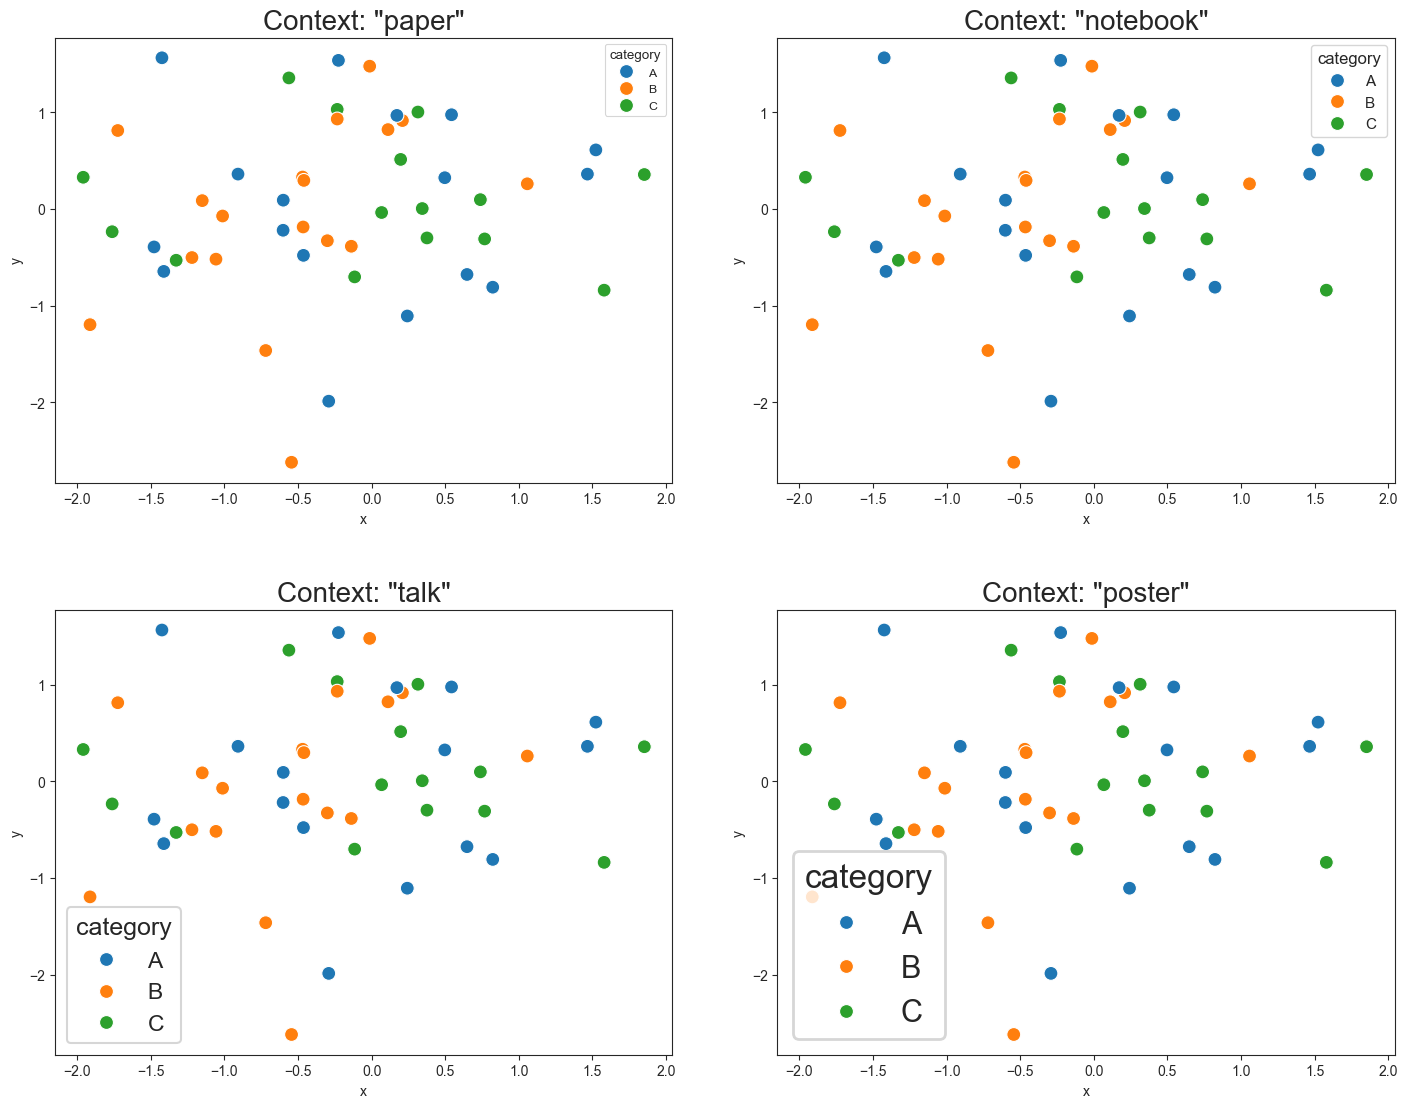

In [3]:
np.random.seed(42)
data = pd.DataFrame({
    'x': np.random.randn(50),
    'y': np.random.randn(50),
    'category': np.random.choice(['A', 'B', 'C'], 50)
})

contexts = ['paper', 'notebook', 'talk', 'poster']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, context in enumerate(contexts):
    with sns.plotting_context(context): # type: ignore
        ax = axes[i]
        sns.scatterplot(data=data, x='x', y='y', hue='category', s=100, ax=ax)
        ax.set_title(f'Context: "{context}"', fontsize=20)

plt.tight_layout(pad=4.0)
plt.show()

上面的代码中：
- `with sns.plotting_context(context):`：在 `with` 语句块中临时应用指定的上下文样式，确保每个子图使用不同的上下文设置；
- `ax.set_title(f'Context: "{context}"', fontsize=20)`：图表标题原本也受上下文影响，但这里将标题字体大小固定为 `20` 会覆盖上下文中的字体大小设定，以便更清晰地展示不同上下文对图表其他元素的影响；
- `plt.tight_layout(pad=4.0)`：增加子图的内边距，防止标题重叠。

#### 调色板

`seaborn` 提供了丰富的调色板选项：通过修改绘图函数的 `palette` 参数，可以改变图表的配色。

下面的代码展示了如何使用内置的不同调色板：

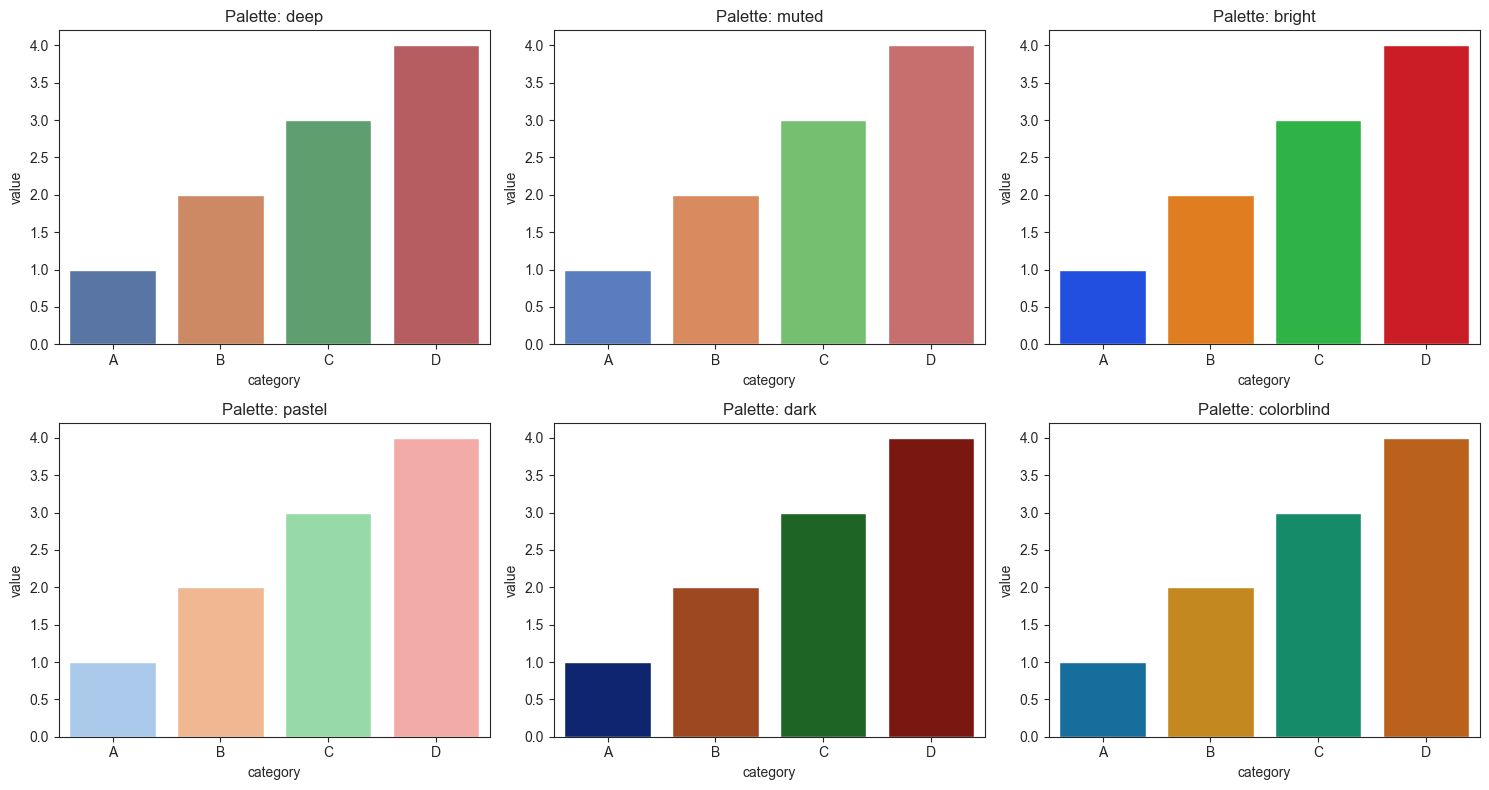

In [4]:
x_data = ['A', 'B', 'C', 'D']
y_data = [1, 2, 3, 4]
df = pd.DataFrame({'category': x_data, 'value': y_data})

palettes = ['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, palette in enumerate(palettes):
    ax = axes[i]
    sns.barplot(data=df, x='category', y='value', palette=palette, ax=ax)
    ax.set_title(f'Palette: {palette}')

plt.tight_layout()
plt.show()

## 绘图方法

### 分布图

分布图是用于展示数据分布情况的图表类型，`seaborn` 提供了多种分布图绘制方法，常用的有以下几种：
- 直方图（*Histogram*）：使用 `sns.histplot()` 函数绘制，适用于展示单变量数据的频率分布；
- 核密度估计图（*KDE Plot*）：使用 `sns.kdeplot()` 函数绘制，适用于展示数据的概率密度分布；
- 地毯图（*Rug Plot*）：使用 `sns.rugplot()` 函数绘制，适用于展示数据点在轴上的分布情况；
- 分布图（*Dist Plot*）：使用 `sns.displot()` 函数绘制，结合了直方图、核密度估计图和地毯图，适用于综合展示数据的分布特征；
- ECDF 图（*Empirical Cumulative Distribution Function Plot*）：使用 `sns.ecdfplot()` 函数绘制，适用于展示数据的累积分布情况。

设置中文字体为微软雅黑，并且能够正常显示负号

In [5]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

`sns.histplot(data, x, y, hue, bins, kde, stat, element)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `bins`：直方图的箱数
- `kde`：是否叠加核密度估计曲线
- `stat`：统计量，可为 `'count'`, `'frequency'`, `'density'`

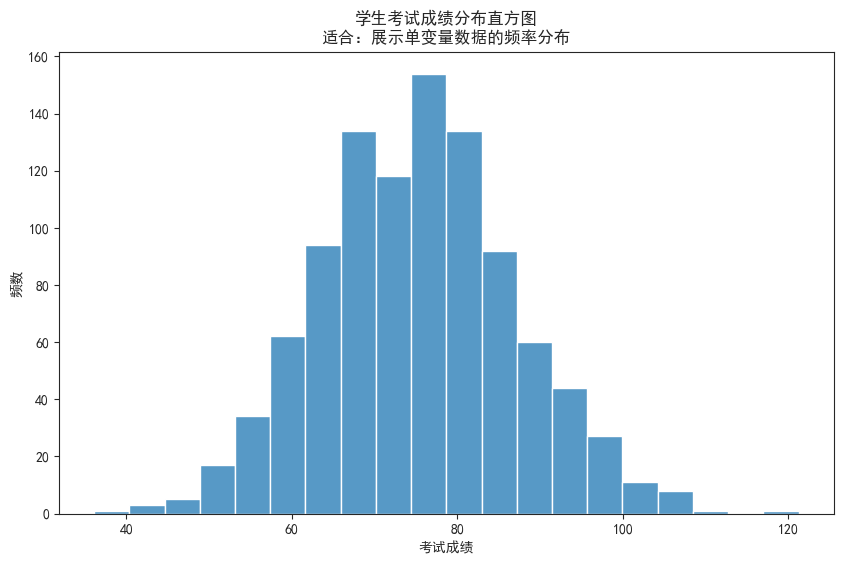

In [6]:
# 生成数据：模拟考试成绩（正态分布）
np.random.seed(42)
exam_scores = np.random.normal(75, 12, 1000)

plt.figure(figsize=(10, 6))
sns.histplot(data=exam_scores, bins=20, kde=False)
plt.title('学生考试成绩分布直方图\n适合：展示单变量数据的频率分布')
plt.xlabel('考试成绩')
plt.ylabel('频数')
plt.show()

`kdeplot(data, x, y, hue, fill, bw_adjust, cut, common_norm)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `fill`：是否填充曲线下方区域
- `bw_adjust`：带宽调整参数，控制平滑程度
- `cut`：控制曲线延伸范围的参数
- `common_norm`：是否对所有组进行归一化

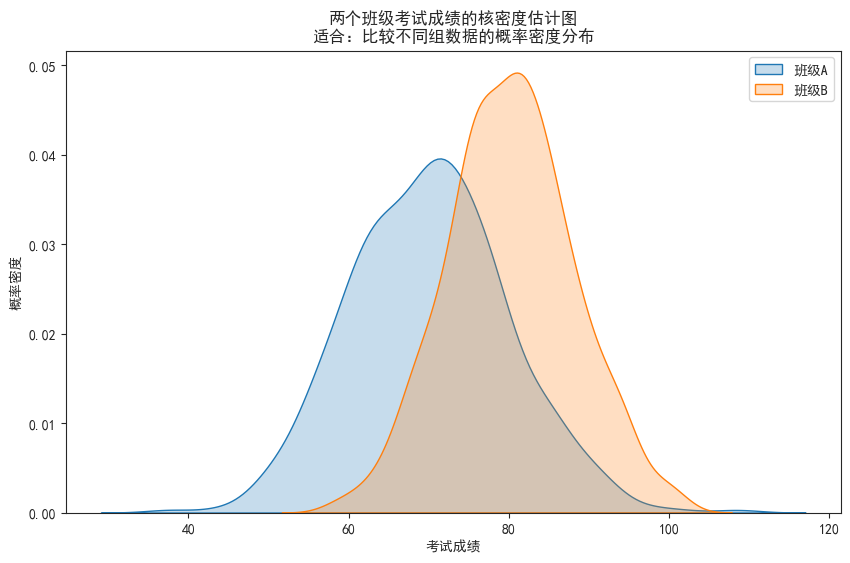

In [7]:
# 生成数据：两个不同班级的考试成绩
np.random.seed(42)
class_a = np.random.normal(70, 10, 500)
class_b = np.random.normal(80, 8, 500)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=class_a, label='班级A', fill=True)
sns.kdeplot(data=class_b, label='班级B', fill=True)
plt.title('两个班级考试成绩的核密度估计图\n适合：比较不同组数据的概率密度分布')
plt.xlabel('考试成绩')
plt.ylabel('概率密度')
plt.legend()
plt.show()

`sns.rugplot(data, x, y, hue, height, axis)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `height`：地毯线的高度
- `axis`：绘制轴，可为 `'x'`，`'y'`

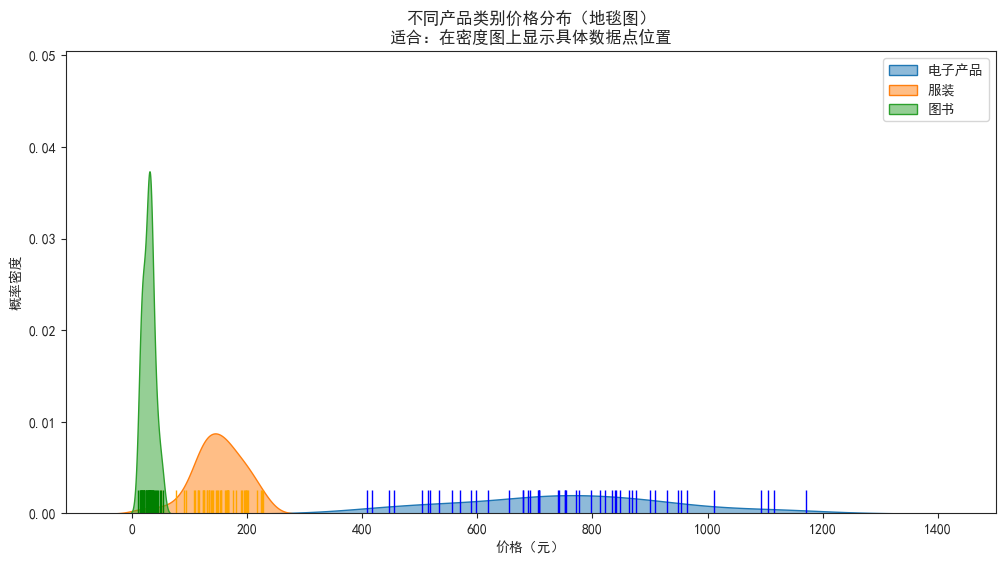

In [8]:
# 生成数据：不同产品类别的价格分布
np.random.seed(42)
electronics = np.random.normal(800, 200, 50)  # 电子产品价格
clothing = np.random.normal(150, 50, 50)      # 服装价格
books = np.random.normal(30, 10, 50)          # 图书价格

plt.figure(figsize=(12, 6))

#可选kde辅助展示理解
sns.kdeplot(data=electronics, label='电子产品', fill=True, alpha=0.5)
sns.kdeplot(data=clothing, label='服装', fill=True, alpha=0.5)
sns.kdeplot(data=books, label='图书', fill=True, alpha=0.5)

# 添加地毯图
sns.rugplot(data=electronics, height=0.05, color='blue')
sns.rugplot(data=clothing, height=0.05, color='orange')
sns.rugplot(data=books, height=0.05, color='green')

plt.title('不同产品类别价格分布（地毯图）\n适合：在密度图上显示具体数据点位置')
plt.xlabel('价格（元）')
plt.ylabel('概率密度')
plt.legend()
plt.show()

`sns.displot(data, x, y, hue, kind, bins, kde, rug)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `kind`：图表类型，可为 `'hist'`, `'kde'`, `'ecdf'`
- `kde`：是否显示核密度估计曲线
- `rug`：是否显示地毯图

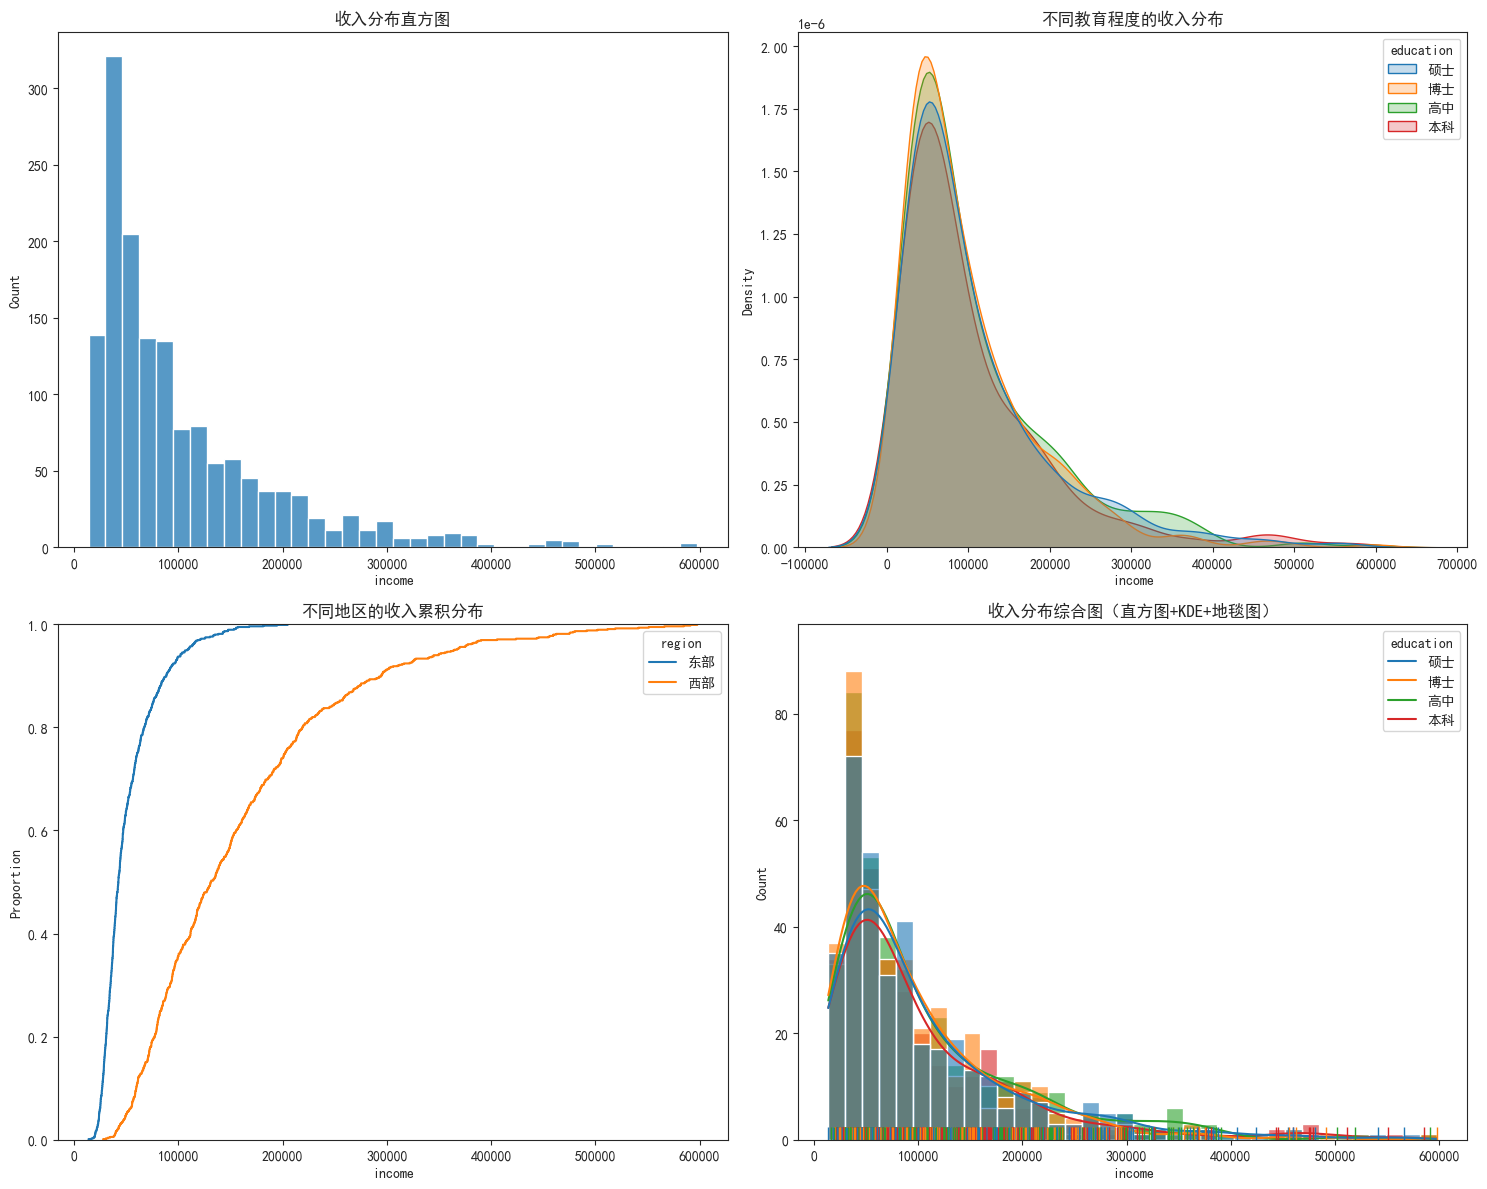

In [9]:
# 创建教育程度-收入综合数据集
np.random.seed(42)
comprehensive_data = pd.DataFrame({
    'income': np.concatenate([
        np.random.lognormal(10.5, 0.3, 500),  # 低收入群体
        np.random.lognormal(11.2, 0.4, 500),  # 中等收入群体
        np.random.lognormal(12.0, 0.5, 500)   # 高收入群体
    ]),
    'education': np.random.choice(['高中', '本科', '硕士', '博士'], 1500),
    'region': ['东部'] * 750 + ['西部'] * 750
})

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 基础直方图 (左上)
sns.histplot(data=comprehensive_data, x='income', ax=axes[0,0])
axes[0,0].set_title('收入分布直方图')

# 2. 按教育程度分组的KDE (右上)
sns.kdeplot(data=comprehensive_data, x='income', hue='education', ax=axes[0,1], fill=True)
axes[0,1].set_title('不同教育程度的收入分布')

# 3. 按地区分组的ECDF (左下)
sns.ecdfplot(data=comprehensive_data, x='income', hue='region', ax=axes[1,0])
axes[1,0].set_title('不同地区的收入累积分布')

# 4. 综合分布图 (右下) - 使用 histplot + kdeplot + rugplot 组合
sns.histplot(data=comprehensive_data, x='income', hue='education', 
             kde=True, ax=axes[1,1], alpha=0.6, multiple='layer')
sns.rugplot(data=comprehensive_data, x='income', hue='education', ax=axes[1,1])
axes[1,1].set_title('收入分布综合图（直方图+KDE+地毯图）')

plt.tight_layout()
plt.show()

`sns.ecdfplot(data, x, y, hue, stat, complementary)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `stat`：统计量，可为 `'count'`, `'proportion'`, `'percent'`
- `complementary`：是否绘制互补累积分布

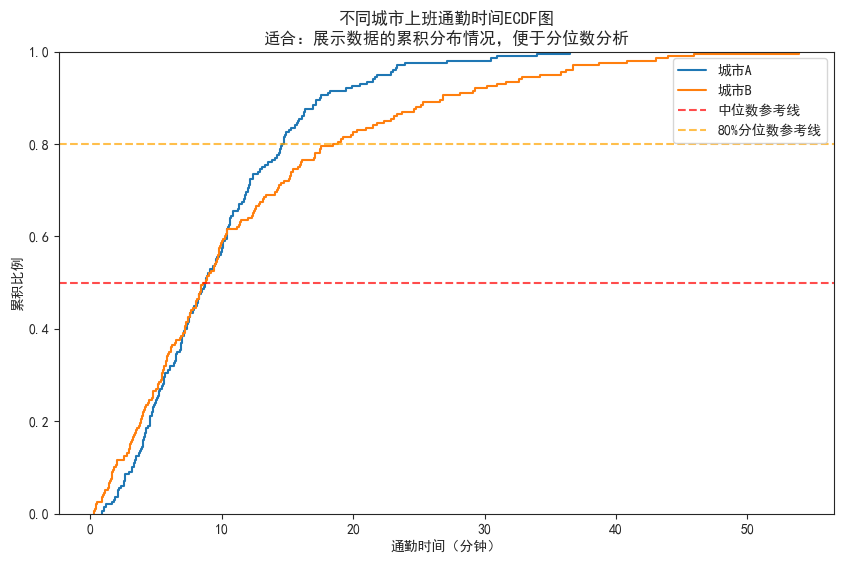

In [10]:
# 生成数据：不同城市上班通勤时间
np.random.seed(42)
city_a = np.random.gamma(2, 5, 200)    # 城市A：通勤时间较长
city_b = np.random.gamma(1.5, 8, 200)  # 城市B：通勤时间差异大

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=city_a, label='城市A')
sns.ecdfplot(data=city_b, label='城市B')

# 添加一些参考线
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='中位数参考线')
plt.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, label='80%分位数参考线')

plt.title('不同城市上班通勤时间ECDF图\n适合：展示数据的累积分布情况，便于分位数分析')
plt.xlabel('通勤时间（分钟）')
plt.ylabel('累积比例')
plt.legend()
plt.show()

#### 分布图-总结表

| 图表类型 | 适合的数据/问题 | 关键优势 |
|---------|----------------|----------|
| **直方图** | 单变量频率分布 | 直观显示数据分布区间和频数 |
| **KDE图** | 概率密度估计 | 平滑显示分布形状，便于比较 |
| **地毯图** | 数据点具体位置 | 避免过度平滑，显示真实数据 |
| **综合分布图** | 全面分布分析 | 结合多种视图，信息丰富 |
| **ECDF图** | 累积分布分析 | 便于计算分位数和比例分析 |

### 关系图

关系图用于展示两个或多个变量之间的关系，`seaborn` 提供了多种关系图绘制方法，常用的有以下几种：
- 关系散点图（*Relational Scatter Plot*）：使用 `sns.relplot()` 函数绘制，支持用点或线展示，并支持分面展示；
- 散点图（*Scatter Plot*）：使用 `sns.scatterplot()` 函数绘制；
- 线图（*Line Plot*）：使用 `sns.lineplot()` 函数绘制。

`sns.relplot(data, x, y, hue, size, style, kind, col, row)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `size`：点的大小变量名
- `style`：点的样式变量名
- `kind`：图表类型，可为 `'scatter'`, `'line'`
- `col`：列分面变量名
- `row`：行分面变量名

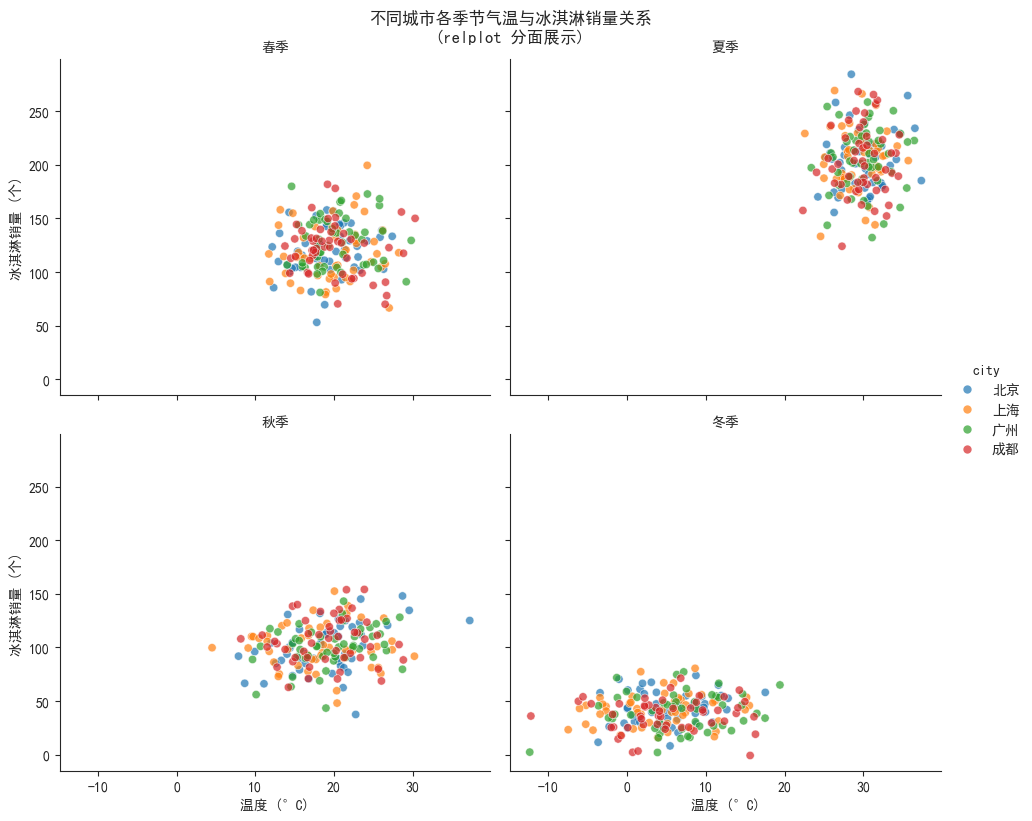

In [11]:
# 生成数据：不同城市的气温与冰淇淋销量关系
np.random.seed(42)
cities = ['北京', '上海', '广州', '成都']
seasons = ['春', '夏', '秋', '冬']

data = []
for city in cities:
    for season in seasons:
        n = 50
        if season == '夏':
            temp = np.random.normal(30, 3, n)
            sales = np.random.normal(200, 30, n) + 0.8 * (temp - 25)
        elif season == '春':
            temp = np.random.normal(20, 4, n)
            sales = np.random.normal(120, 25, n) + 0.6 * (temp - 20)
        elif season == '秋':
            temp = np.random.normal(18, 5, n)
            sales = np.random.normal(100, 20, n) + 0.5 * (temp - 18)
        else:  # 冬
            temp = np.random.normal(5, 6, n)
            sales = np.random.normal(40, 15, n) + 0.3 * (temp - 5)
        
        for t, s in zip(temp, sales):
            data.append({'city': city, 'season': season, 'temperature': t, 'sales': s})

df = pd.DataFrame(data)

# 使用 relplot 分面展示
g = sns.relplot(data=df, x='temperature', y='sales', hue='city', 
                col='season', col_wrap=2, kind='scatter', alpha=0.7,
                height=4, aspect=1.2)
g.set_axis_labels('温度 (°C)', '冰淇淋销量 (个)')
g.set_titles('{col_name}季')
plt.suptitle('不同城市各季节气温与冰淇淋销量关系\n(relplot 分面展示)', y=1.02)
plt.show()

`sns.scatterplot(data, x, y, hue, size, style, palette, sizes)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：颜色分组变量名
- `size`：大小分组变量名
- `style`：点的样式变量名
- `palette`：调色板
- `sizes`：大小范围列表

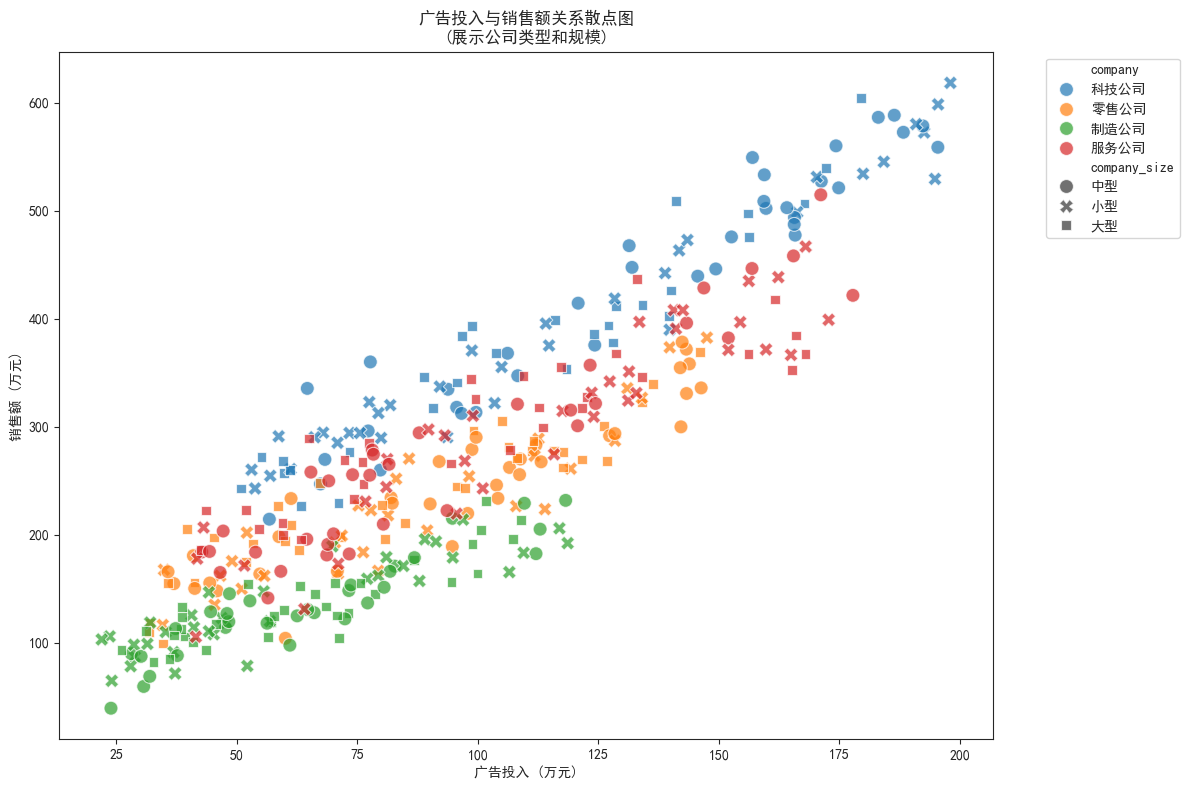

In [12]:
# 生成数据：广告投入与销售额关系
np.random.seed(42)
companies = ['科技公司', '零售公司', '制造公司', '服务公司']

ad_sales_data = []
for company in companies:
    n = 100
    if company == '科技公司':
        ad_spend = np.random.uniform(50, 200, n)
        sales = 100 + 2.5 * ad_spend + np.random.normal(0, 30, n)
    elif company == '零售公司':
        ad_spend = np.random.uniform(30, 150, n)
        sales = 80 + 1.8 * ad_spend + np.random.normal(0, 25, n)
    elif company == '制造公司':
        ad_spend = np.random.uniform(20, 120, n)
        sales = 60 + 1.2 * ad_spend + np.random.normal(0, 20, n)
    else:  # 服务公司
        ad_spend = np.random.uniform(40, 180, n)
        sales = 90 + 2.0 * ad_spend + np.random.normal(0, 35, n)
    
    for ad, sale in zip(ad_spend, sales):
        ad_sales_data.append({
            'company': company, 
            'ad_spend': ad, 
            'sales': sale,
            'company_size': np.random.choice(['小型', '中型', '大型'])
        })

ad_sales_df = pd.DataFrame(ad_sales_data)

# 散点图
plt.figure(figsize=(12, 8))
sns.scatterplot(data=ad_sales_df, x='ad_spend', y='sales', 
                hue='company', style='company_size', s=100, alpha=0.7)
plt.title('广告投入与销售额关系散点图\n(展示公司类型和规模)')
plt.xlabel('广告投入 (万元)')
plt.ylabel('销售额 (万元)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.lineplot(data, x, y, hue, size, style, palette, dashes)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：颜色分组变量名
- `size`：大小分组变量名
- `style`：线型分组变量名
- `palette`：调色板
- `dashes`：是否使用虚线

线图经常用于展示时间序列数据的变化趋势，例如股票价格、气温变化等，所以我们构造一些时序数据：

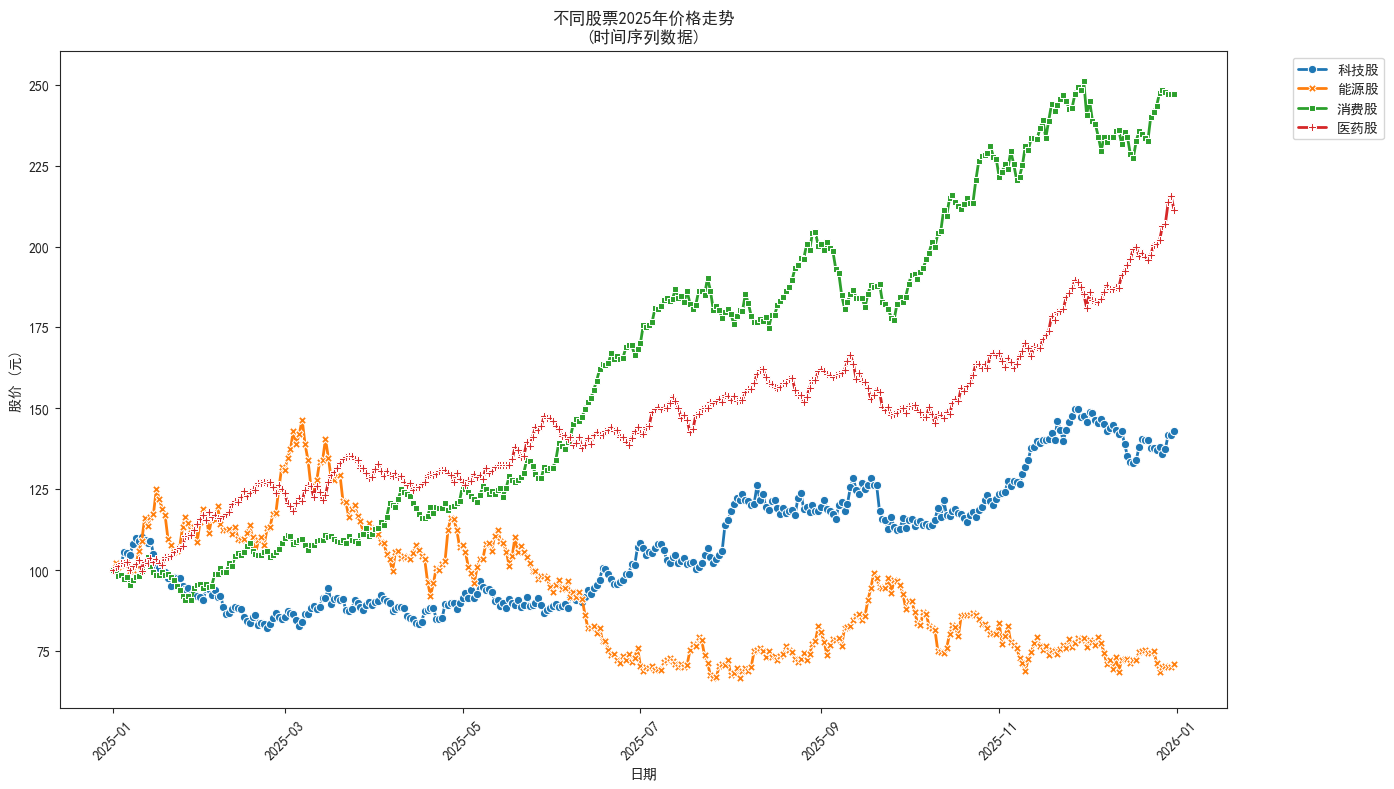

In [13]:
# 生成数据：股票价格时间序列
np.random.seed(42)
dates = pd.date_range('2025-01-01', '2025-12-31', freq='D')
stocks = ['科技股', '能源股', '消费股', '医药股']

stock_data = []
for stock in stocks:
    base_price = 100
    prices = [base_price]
    
    for i in range(1, len(dates)):
        if stock == '科技股':
            change = np.random.normal(0.1, 2, 1)[0]  # 高波动
        elif stock == '能源股':
            change = np.random.normal(0.05, 3, 1)[0]  # 更高波动
        elif stock == '消费股':
            change = np.random.normal(0.08, 1.5, 1)[0]  # 中等波动
        else:  # 医药股
            change = np.random.normal(0.12, 1.2, 1)[0]  # 稳定增长
        
        new_price = prices[-1] * (1 + change/100)
        prices.append(new_price)
    
    for date, price in zip(dates, prices):
        stock_data.append({
            'date': date,
            'stock': stock,
            'price': price,
            'month': date.month
        })

stock_df = pd.DataFrame(stock_data)

# 线图
plt.figure(figsize=(14, 8))
sns.lineplot(data=stock_df, x='date', y='price', hue='stock', 
             style='stock', markers=True, dashes=False, linewidth=2)
plt.title('不同股票2025年价格走势\n(时间序列数据)')
plt.xlabel('日期')
plt.ylabel('股价 (元)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 关系图-总结表

| 函数 | 适用场景 | 关键特性 | 示例数据 |
|------|----------|----------|----------|
| `sns.relplot()` | 多维度关系分析 | 支持分面、多种图表类型 | 分城市分季节的气温销量 |
| `sns.scatterplot()` | 两个变量关系 | 颜色、形状编码 | 广告投入与销售额 |
| `sns.lineplot()` | 时间序列趋势 | 连接数据点、趋势线 | 股票价格走势 |

**选择指南：**
- 需要分面展示：使用 `relplot` + `col`/`row` 参数
- 基础两个变量关系：使用 `scatterplot`
- 时间序列/趋势分析：使用 `lineplot`
- 复杂多维分析：使用 `relplot` 配合多种编码

### 分类图

分类图用于展示分类变量与数值变量之间的关系，`seaborn` 提供了多种分类图绘制方法，常用的有以下几种：
- 分类图（*Categorical Plot*）：使用 `sns.catplot()` 函数绘制，支持多种图表类型，并支持分面展示；
- 条形散点图（*Strip Plot*）：使用 `sns.stripplot()` 函数绘制；
- 蜂群图（*Swarm Plot*）：使用 `sns.swarmplot()` 函数绘制；
- 箱线图（*Box Plot*）：使用 `sns.boxplot()` 函数绘制；
- 小提琴图（*Violin Plot*）：使用 `sns.violinplot()` 函数绘制；
- 增强箱线图（*Enhanced Boxen Plot*）：使用 `sns.boxenplot()` 函数绘制；
- 点图（*Point Plot*）：使用 `sns.pointplot()` 函数绘制；
- 条形图（*Bar Plot*）：使用 `sns.barplot()` 函数绘制；
- 计数图（*Count Plot*）：使用 `sns.countplot()` 函数绘制。

下面先生成一些示例数据，为这一节的分类图共用：

In [14]:
# 创建综合数据集：电商平台产品数据
np.random.seed(42)
categories = ['电子产品', '服装', '家居', '美妆', '食品']
regions = ['华北', '华东', '华南', '西部']
seasons = ['Q1', 'Q2', 'Q3', 'Q4']

data = []
for category in categories:
    for region in regions:
        for season in seasons:
            n = 50
            # 不同品类有不同的价格和销量特征
            if category == '电子产品':
                price = np.random.normal(3000, 800, n)
                sales = np.random.normal(500, 150, n) - 0.1 * (price - 3000)
                rating = np.random.normal(4.5, 0.3, n)
            elif category == '服装':
                price = np.random.normal(200, 80, n)
                sales = np.random.normal(800, 200, n) - 0.2 * (price - 200)
                rating = np.random.normal(4.2, 0.4, n)
            elif category == '家居':
                price = np.random.normal(500, 200, n)
                sales = np.random.normal(300, 100, n) - 0.15 * (price - 500)
                rating = np.random.normal(4.3, 0.35, n)
            elif category == '美妆':
                price = np.random.normal(150, 60, n)
                sales = np.random.normal(600, 180, n) - 0.25 * (price - 150)
                rating = np.random.normal(4.4, 0.3, n)
            else:  # 食品
                price = np.random.normal(50, 20, n)
                sales = np.random.normal(1200, 300, n) - 0.3 * (price - 50)
                rating = np.random.normal(4.6, 0.25, n)
            
            # 季节性调整
            if season == 'Q2':  # 促销季
                sales = sales * 1.3
            elif season == 'Q4':  # 旺季
                sales = sales * 1.5
            
            for p, s, r in zip(price, sales, rating):
                data.append({
                    'category': category,
                    'region': region,
                    'season': season,
                    'price': max(p, 10),
                    'sales': max(s, 10),
                    'rating': min(max(r, 1), 5),  # 限制在1-5之间
                    'profit_margin': np.random.normal(0.2, 0.05)  # 利润率
                })

df = pd.DataFrame(data)

`sns.catplot(data, x, y, hue, kind, col, row, order)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `kind`：图表类型，可为 `'strip'`, `'swarm'`, `'box'`, `'violin'`
- `col`：列分面变量名
- `row`：行分面变量名
- `order`：分类变量的顺序

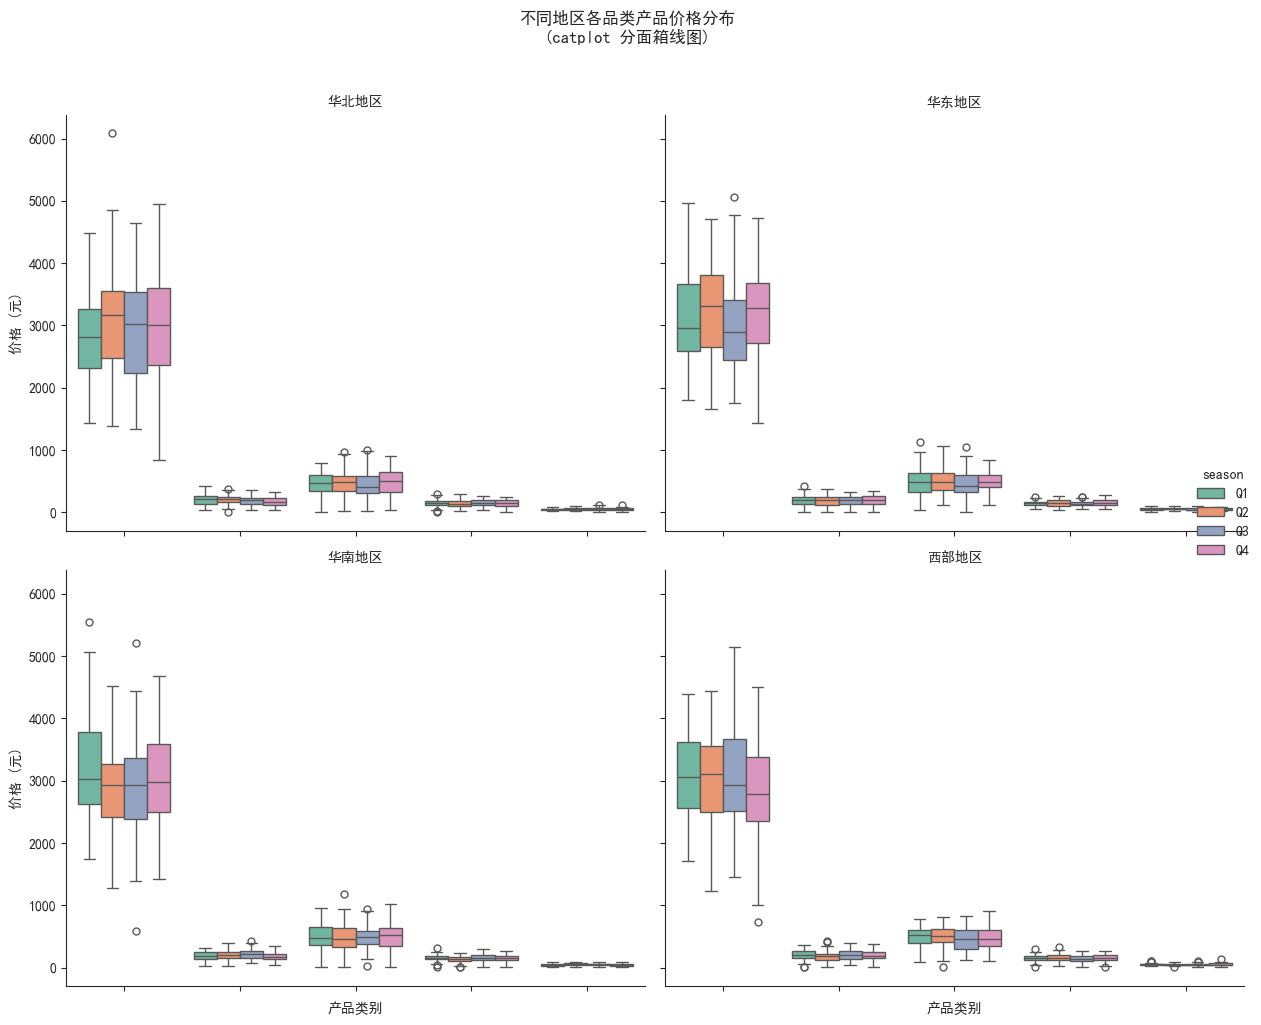

In [15]:
# 使用 catplot 分面展示不同地区的价格分布
g = sns.catplot(data=df, x='category', y='price', hue='season',
                col='region', col_wrap=2, kind='box',
                height=5, aspect=1.2, palette='Set2')
g.set_axis_labels('产品类别', '价格 (元)')
g.set_titles('{col_name}地区')
g.set_xticklabels(rotation=45)
plt.suptitle('不同地区各品类产品价格分布\n(catplot 分面箱线图)', y=1.02)
plt.tight_layout()
plt.show()

`sns.stripplot(data, x, y, hue, order, jitter, dodge)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `jitter`：抖动程度
- `dodge`：是否分组显示
- `alpha`：透明度

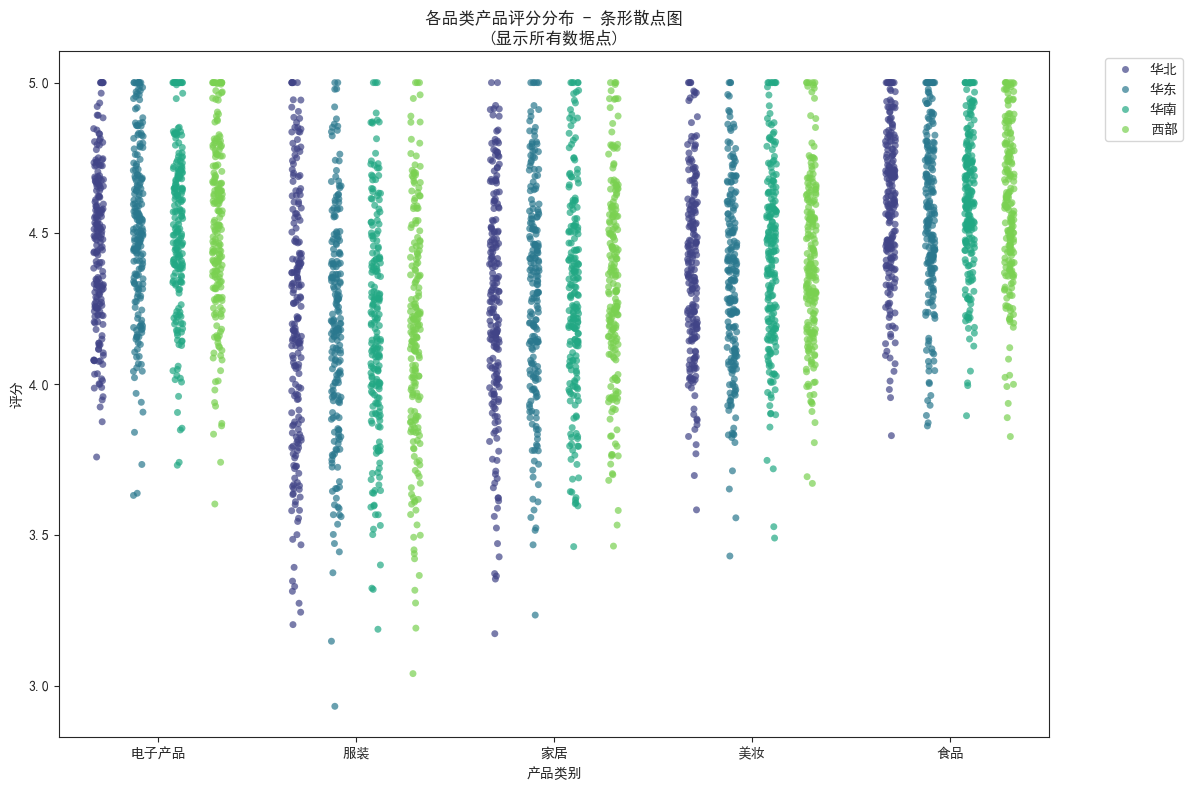

In [16]:
plt.figure(figsize=(12, 8))
sns.stripplot(data=df, x='category', y='rating', hue='region',
              alpha=0.7, jitter=True, dodge=True, palette='viridis')
plt.title('各品类产品评分分布 - 条形散点图\n(显示所有数据点)')
plt.xlabel('产品类别')
plt.ylabel('评分')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.swarmplot(data, x, y, hue, order, dodge)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `dodge`：是否分组显示

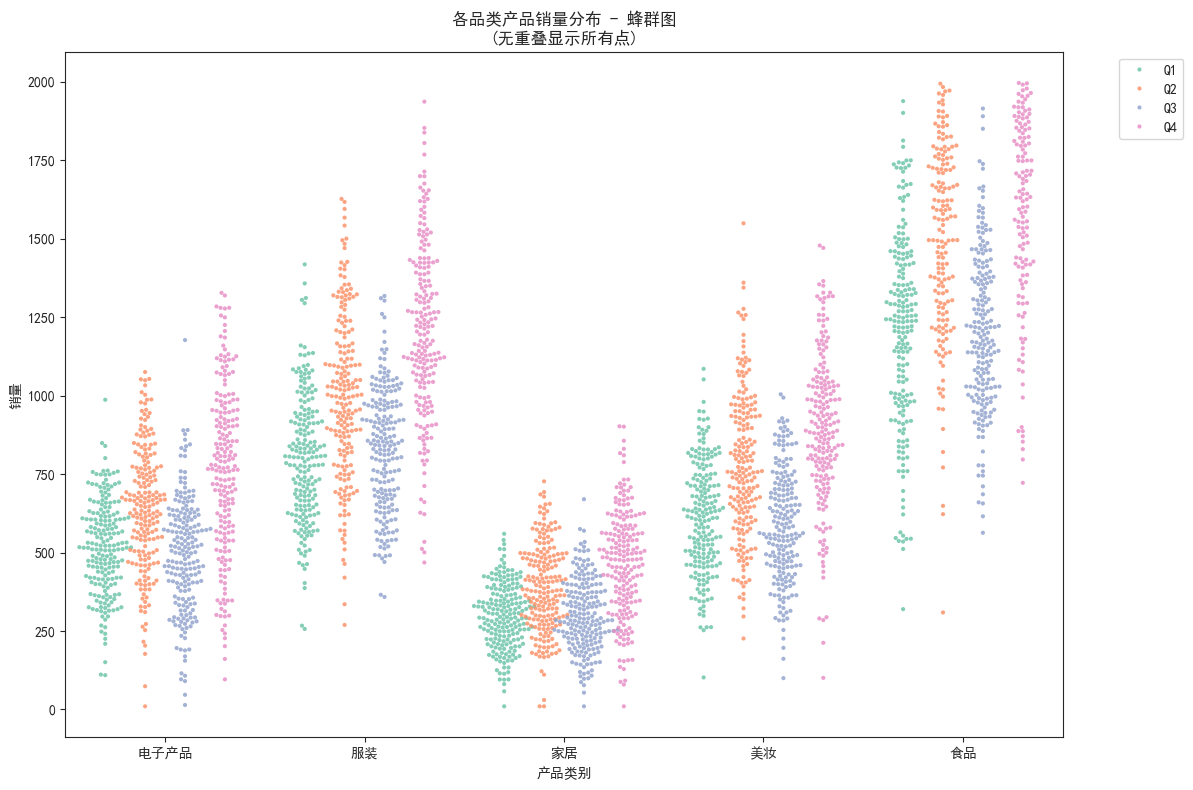

In [17]:
plt.figure(figsize=(12, 8))
sns.swarmplot(data=df[df['sales'] < 2000], x='category', y='sales', hue='season',
              alpha=0.8, dodge=True, palette='Set2', size=3)
plt.title('各品类产品销量分布 - 蜂群图\n(无重叠显示所有点)')
plt.xlabel('产品类别')
plt.ylabel('销量')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.boxplot(data, x, y, hue, order, orient, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平）
- `width`：箱体宽度

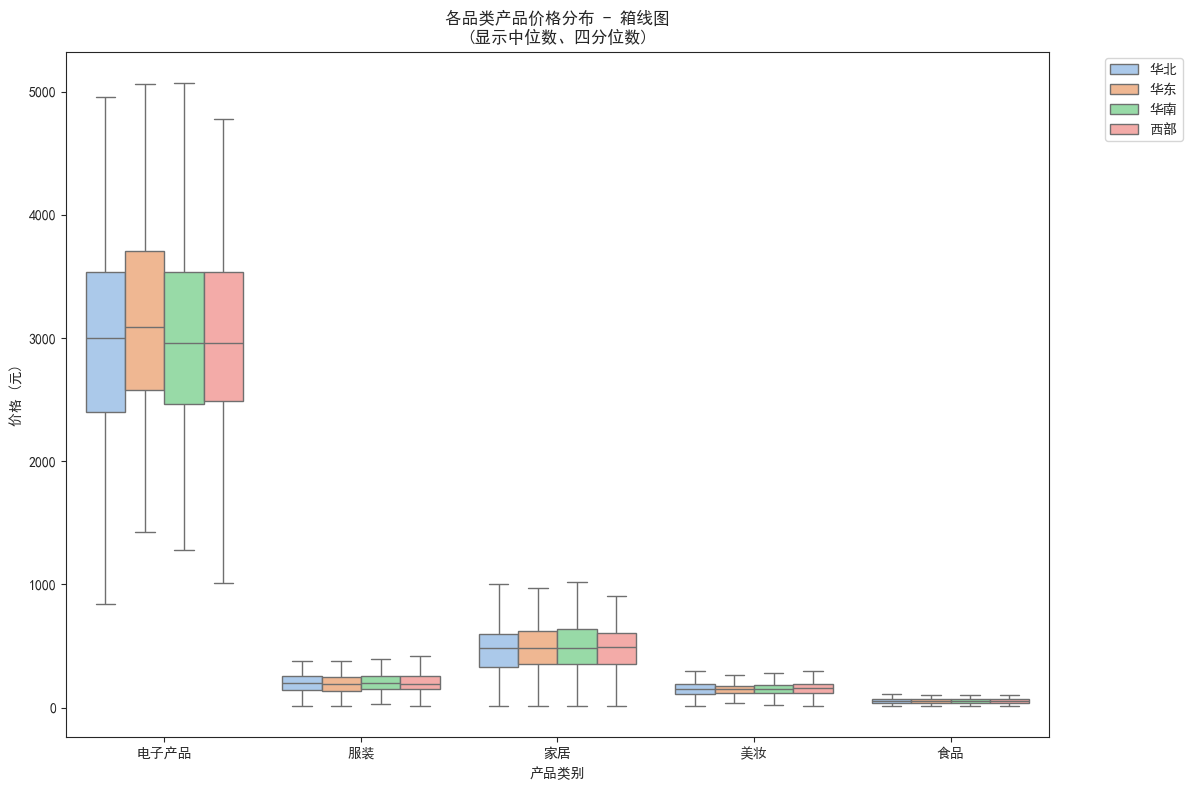

In [18]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='category', y='price', hue='region',
            palette='pastel', showfliers=False)
plt.title('各品类产品价格分布 - 箱线图\n(显示中位数、四分位数)')
plt.xlabel('产品类别')
plt.ylabel('价格 (元)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.violinplot(data, x, y, hue, order, split, scale, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `split`：是否分割小提琴
- `scale`：缩放方式，可为 `'area', 'count', 'width'`
- `width`：小提琴宽度

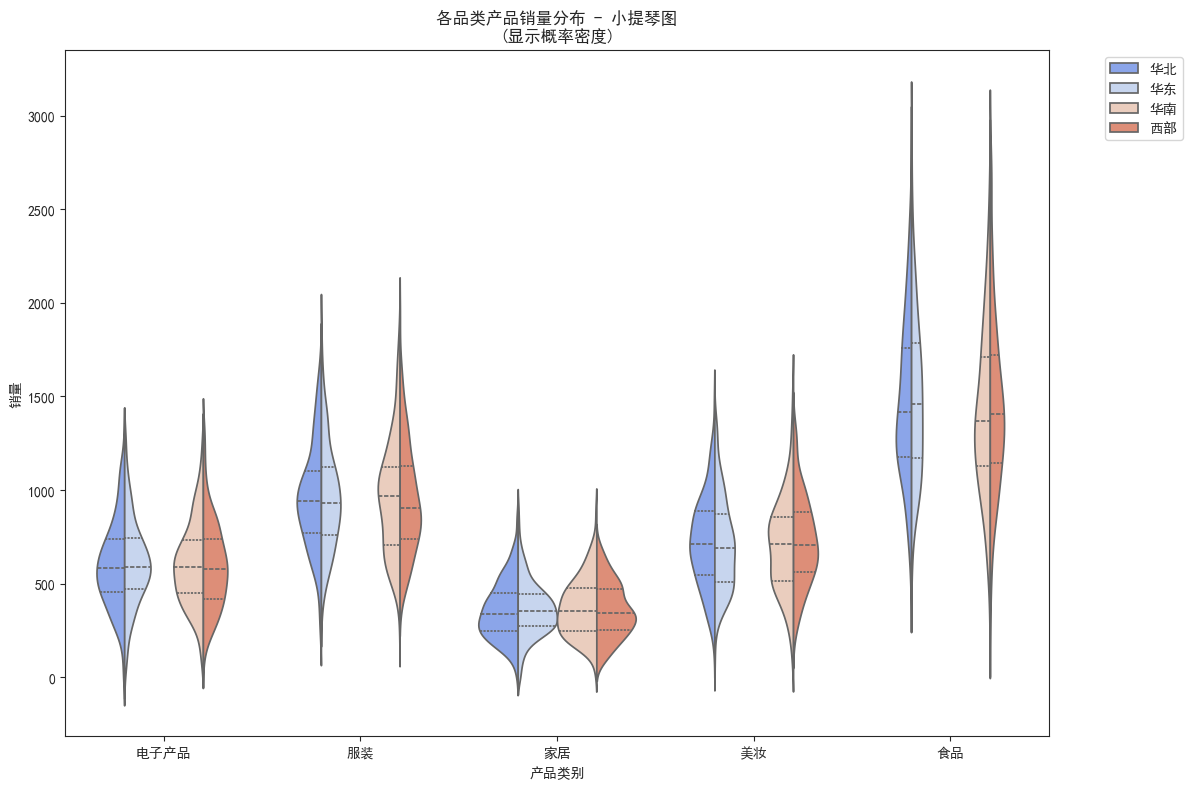

In [19]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x='category', y='sales', hue='region',
               split=True, inner='quart', palette='coolwarm')
plt.title('各品类产品销量分布 - 小提琴图\n(显示概率密度)')
plt.xlabel('产品类别')
plt.ylabel('销量')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.boxenplot(data, x, y, hue, order, orient, width)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：方向，可为 `'v', 'h'`
- `width`：箱体宽度

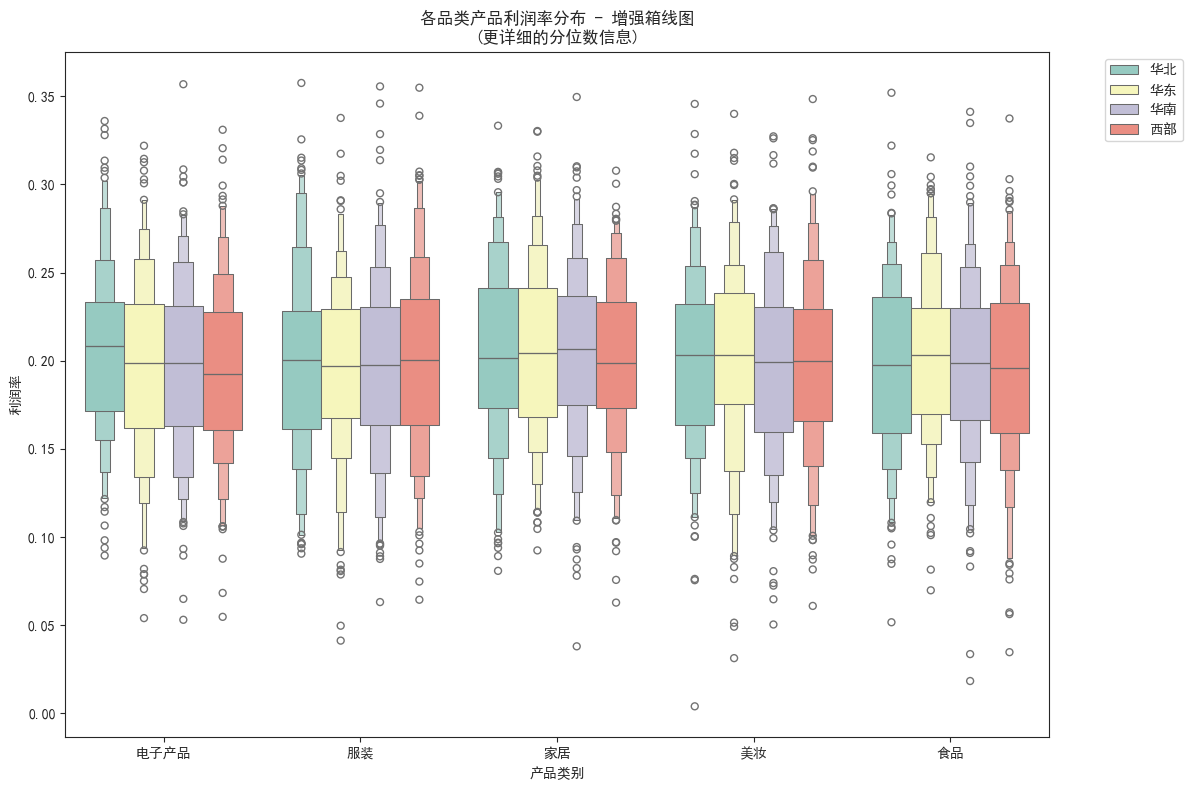

In [20]:
plt.figure(figsize=(12, 8))
sns.boxenplot(data=df, x='category', y='profit_margin', hue='region',
              palette='Set3')
plt.title('各品类产品利润率分布 - 增强箱线图\n(更详细的分位数信息)')
plt.xlabel('产品类别')
plt.ylabel('利润率')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.pointplot(data, x, y, hue, order, ci, capsize, join)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `ci`：置信区间大小
- `capsize`：误差条帽大小
- `join`：是否连接点

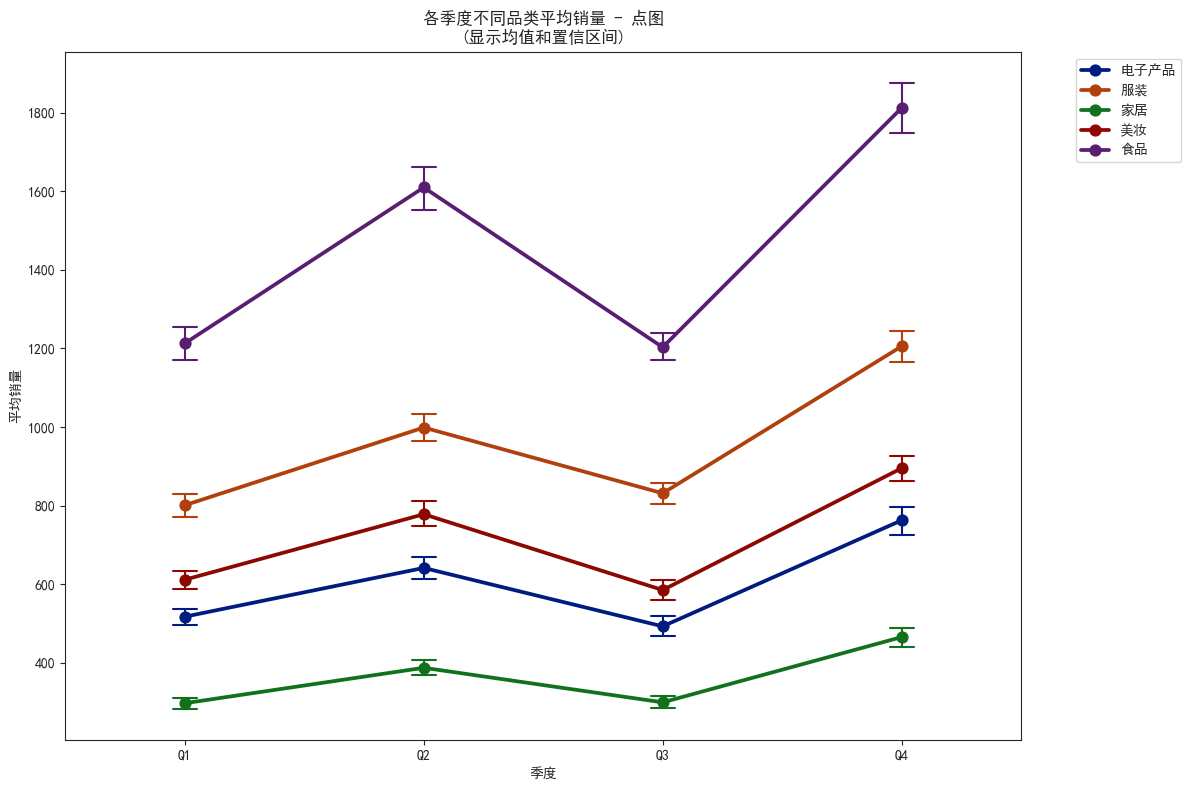

In [21]:
plt.figure(figsize=(12, 8))
sns.pointplot(data=df, x='season', y='sales', hue='category',
              ci=95, capsize=0.1, errwidth=1.5, palette='dark')
plt.title('各季度不同品类平均销量 - 点图\n(显示均值和置信区间)')
plt.xlabel('季度')
plt.ylabel('平均销量')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.barplot(data, x, y, hue, order, orient, ci, estimator)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平）
- `ci`：置信区间大小
- `estimator`：统计函数，可为 `'mean', 'median', 'sum'`

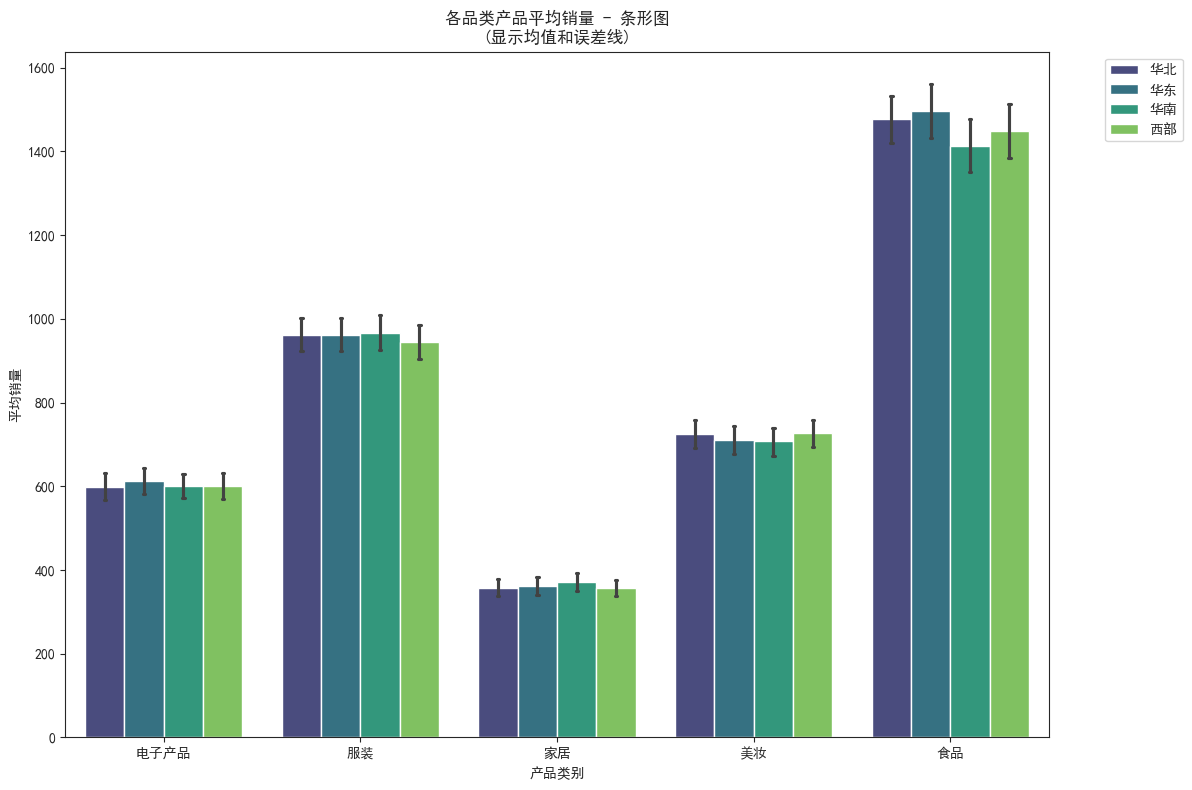

In [22]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='category', y='sales', hue='region',
            ci=95, palette='viridis', capsize=0.05)
plt.title('各品类产品平均销量 - 条形图\n(显示均值和误差线)')
plt.xlabel('产品类别')
plt.ylabel('平均销量')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

`sns.countplot(data, x, y, hue, order, orient)`
- `data`：数据框或数组
- `x`：X 轴分类变量名
- `y`：Y 轴数值变量名
- `hue`：分组变量名
- `order`：分类变量的顺序
- `orient`：图表方向，可为 `'v'`（垂直）或 `'h'`（水平`)

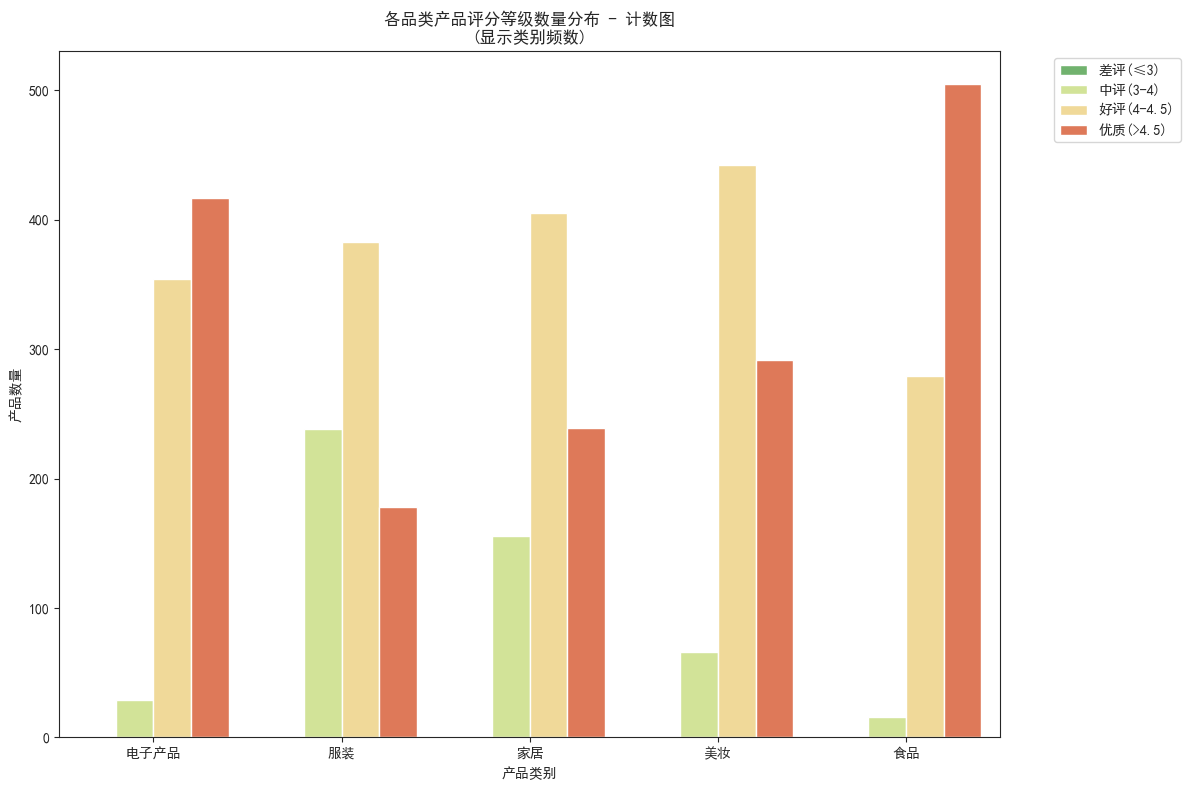

In [23]:
# 创建评分等级数据
df['rating_level'] = pd.cut(df['rating'], 
                           bins=[0, 3, 4, 4.5, 5],
                           labels=['差评(≤3)', '中评(3-4)', '好评(4-4.5)', '优质(>4.5)'])

plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='category', hue='rating_level',
              palette='RdYlGn_r')
plt.title('各品类产品评分等级数量分布 - 计数图\n(显示类别频数)')
plt.xlabel('产品类别')
plt.ylabel('产品数量')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

下面展示对于同一数据集（五大类商品的价格），不同分类图的结果：

c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 42.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


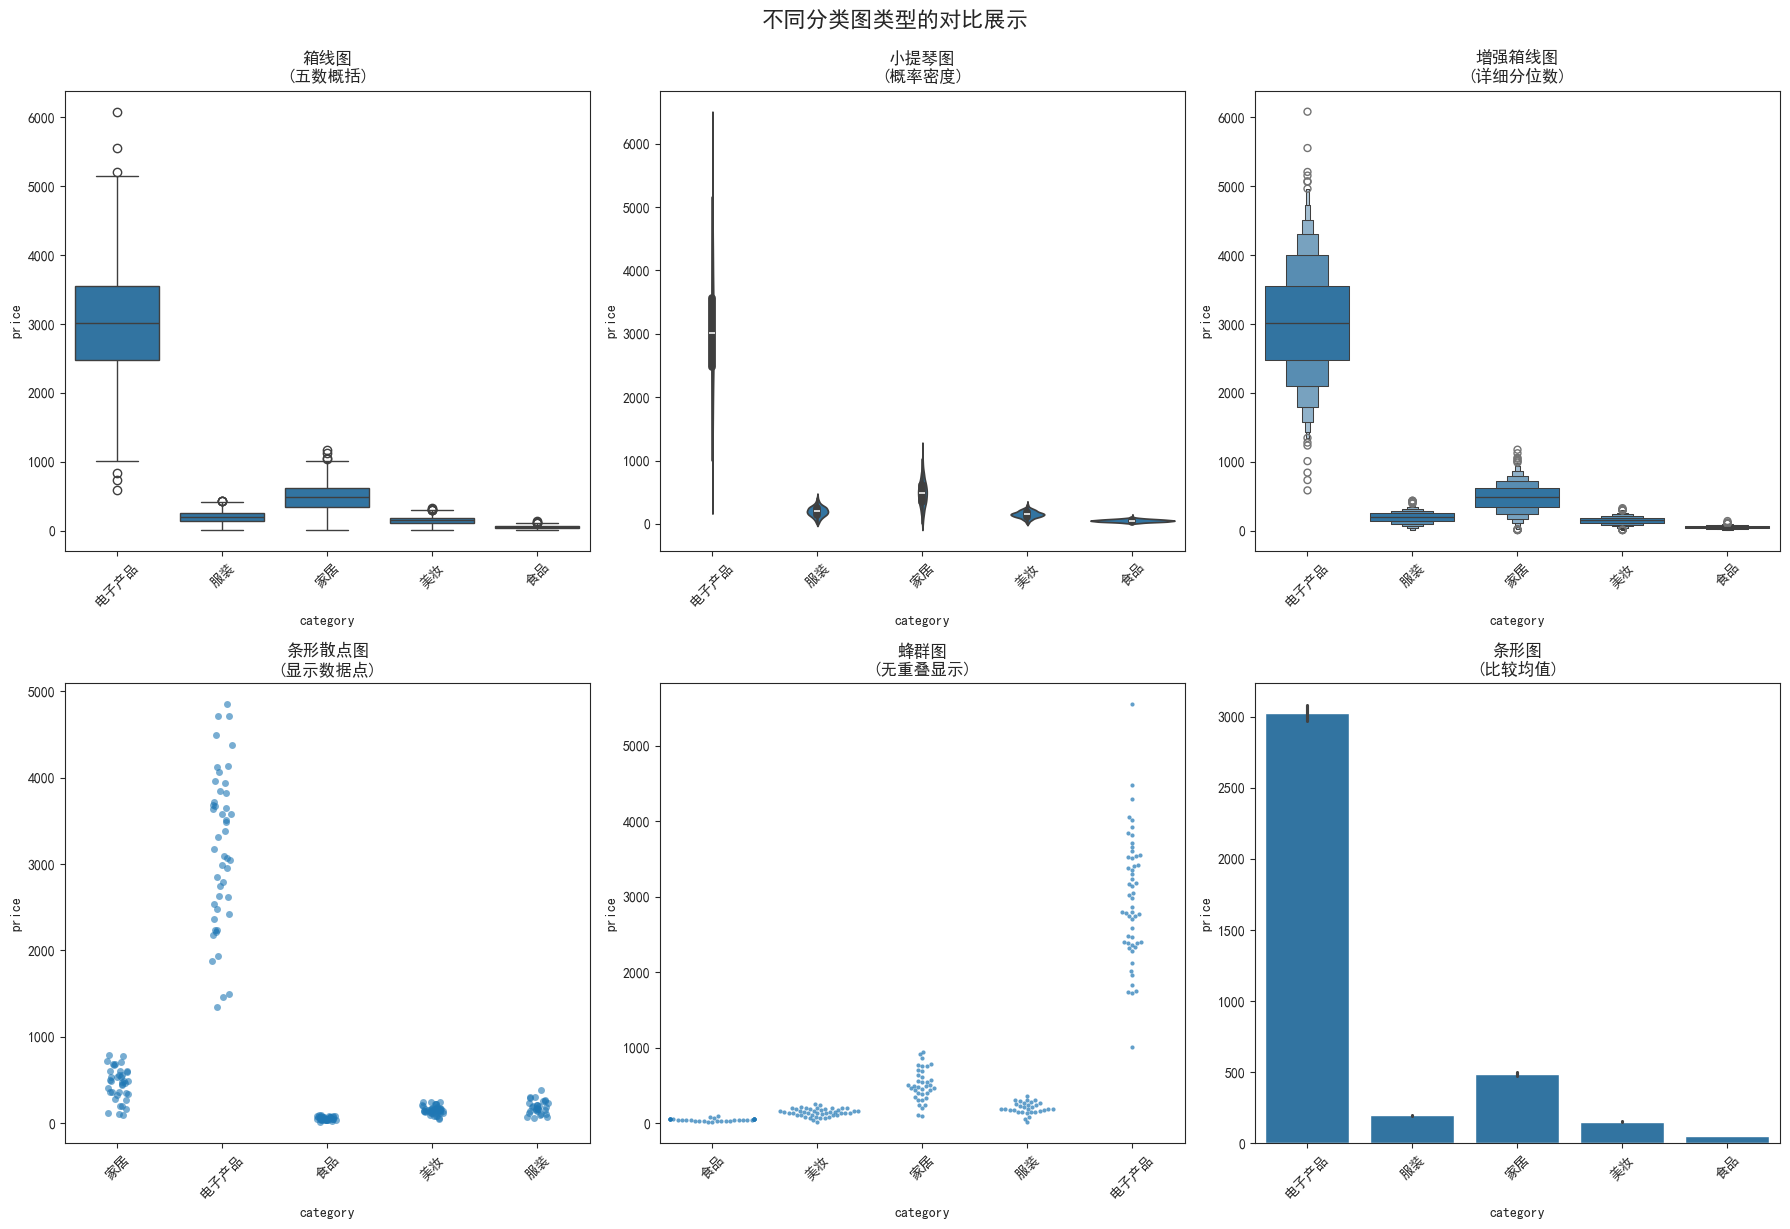

In [24]:
# 创建综合对比图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 箱线图
sns.boxplot(data=df, x='category', y='price', ax=axes[0,0])
axes[0,0].set_title('箱线图\n(五数概括)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. 小提琴图
sns.violinplot(data=df, x='category', y='price', ax=axes[0,1])
axes[0,1].set_title('小提琴图\n(概率密度)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. 增强箱线图
sns.boxenplot(data=df, x='category', y='price', ax=axes[0,2])
axes[0,2].set_title('增强箱线图\n(详细分位数)')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. 条形散点图
sns.stripplot(data=df.sample(200), x='category', y='price', 
              ax=axes[1,0], alpha=0.6, jitter=True)
axes[1,0].set_title('条形散点图\n(显示数据点)')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. 蜂群图
sns.swarmplot(data=df.sample(200), x='category', y='price', 
              ax=axes[1,1], alpha=0.7, size=3)
axes[1,1].set_title('蜂群图\n(无重叠显示)')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. 条形图
sns.barplot(data=df, x='category', y='price', ax=axes[1,2])
axes[1,2].set_title('条形图\n(比较均值)')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('不同分类图类型的对比展示', y=1.02, fontsize=16)
plt.show()


## 总结表

| 图表类型 | 适用场景 | 关键特性 | 数据要求 |
|---------|----------|----------|----------|
| `catplot` | 多维度分面 | 支持多种子图类型 | 分类+数值变量 |
| `stripplot` | 显示所有点 | 数据点抖动 | 中小数据集 |
| `swarmplot` | 无重叠显示 | 点自动排列 | 中小数据集 |
| `boxplot` | 分布概括 | 五数概括+离群值 | 各种数据集 |
| `violinplot` | 密度展示 | 核密度估计 | 各种数据集 |
| `boxenplot` | 详细分位数 | 更多分位信息 | 较大数据集 |
| `pointplot` | 趋势比较 | 均值+置信区间 | 趋势分析 |
| `barplot` | 均值比较 | 柱状图+误差线 | 均值比较 |
| `countplot` | 频数统计 | 计数展示 | 纯分类变量 |

**选择指南：**
- 探索数据分布：箱线图、小提琴图、增强箱线图
- 显示具体数据点：条形散点图、蜂群图
- 比较均值：条形图、点图
- 频数统计：计数图
- 多维度分析：catplot 分面展示

### 回归图

回归图用于展示变量之间的回归关系，`seaborn` 提供了多种回归图绘制方法，常用的有以下几种：
- 回归图（*Regression Plot*）：使用 `sns.regplot()` 函数绘制，适用于展示单变量回归关系；
- 线性模型图（*Linear Model Plot*）：使用 `sns.lmplot()` 函数绘制，适用于展示多变量回归关系，并支持分面展示；
- 残差图（*Residual Plot*）：使用 `sns.residplot()` 函数绘制，适用于展示回归模型的残差分布情况。

先生成一些房屋销售的示例数据：

In [25]:
# 创建综合数据集：房屋销售数据
np.random.seed(42)
n_samples = 500

# 生成非线性关系的数据
house_data = pd.DataFrame({
    'area': np.random.uniform(50, 200, n_samples),  # 面积
    'bedrooms': np.random.choice([1, 2, 3, 4, 5], n_samples),  # 卧室数量
    'location': np.random.choice(['市中心', '郊区', '学区'], n_samples),  # 位置
    'age': np.random.exponential(10, n_samples),  # 房龄
    'metro_distance': np.random.exponential(5, n_samples)  # 地铁距离
})

# 创建复杂的房价模型（非线性关系）
area_effect = 5000 * house_data['area'] + 20 * (house_data['area'] - 100)**2
bedroom_effect = 200000 * (house_data['bedrooms'] - 1)
location_effect = house_data['location'].map({'市中心': 500000, '学区': 300000, '郊区': 100000})
age_effect = -10000 * house_data['age']
metro_effect = -8000 * house_data['metro_distance']

# 添加交互效应和噪声
base_price = 500000 + area_effect + bedroom_effect + location_effect + age_effect + metro_effect
noise = np.random.normal(0, 80000, n_samples)

house_data['price'] = base_price + noise
house_data['price'] = house_data['price'].astype(int)

print("数据集前5行：")
print(house_data.head())

数据集前5行：
         area  bedrooms location        age  metro_distance    price
0  106.181018         1       学区   3.738967        1.324032  1343319
1  192.607146         1       郊区   3.867553        1.247455  1615028
2  159.799091         1       学区  12.888870        0.954305  1481540
3  139.798773         5       郊区  13.697795        5.331553  1962942
4   73.402796         4       学区   2.235926        9.419896  1587595


由于涉及到了机器学习的相关内容，所以导入必要的库

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

`sns.regplot(data, x, y, hue, scatter, fit_reg, ci)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `hue`：分组变量名
- `scatter`：是否绘制散点图
- `scatter_kws`：散点图样式参数
- `line_kws`：回归线样式参数
- `fit_reg`：是否拟合回归线
- `ci`：置信区间大小

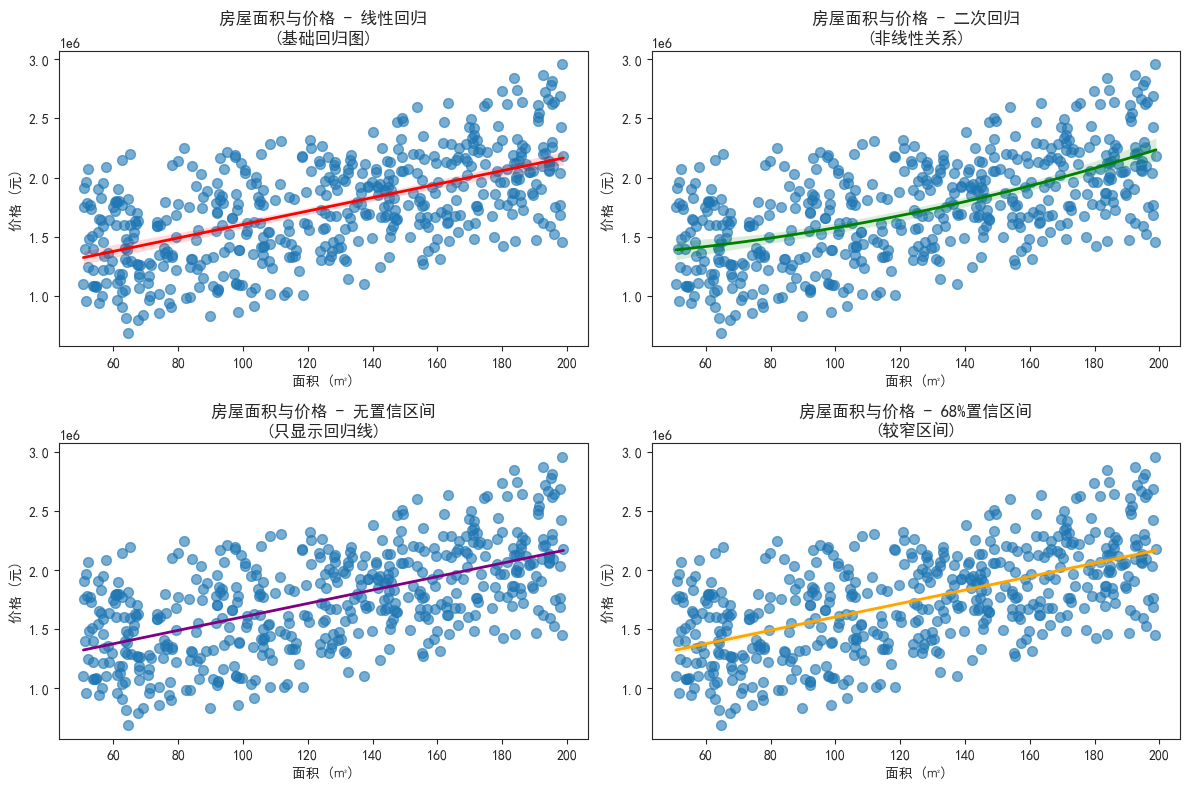

In [27]:
# 基础回归图：面积 vs 价格
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.regplot(data=house_data, x='area', y='price', 
            scatter_kws={'alpha':0.6, 's':50},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('房屋面积与价格 - 线性回归\n(基础回归图)')
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (元)')

plt.subplot(2, 2, 2)
sns.regplot(data=house_data, x='area', y='price', order=2,
            scatter_kws={'alpha':0.6, 's':50},
            line_kws={'color': 'green', 'linewidth': 2})
plt.title('房屋面积与价格 - 二次回归\n(非线性关系)')
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (元)')

plt.subplot(2, 2, 3)
# 无置信区间的回归
sns.regplot(data=house_data, x='area', y='price', ci=None,
            scatter_kws={'alpha':0.6, 's':50},
            line_kws={'color': 'purple', 'linewidth': 2})
plt.title('房屋面积与价格 - 无置信区间\n(只显示回归线)')
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (元)')

plt.subplot(2, 2, 4)
# 不同置信区间比较
sns.regplot(data=house_data, x='area', y='price', ci=68,
            scatter_kws={'alpha':0.6, 's':50},
            line_kws={'color': 'orange', 'linewidth': 2})
plt.title('房屋面积与价格 - 68%置信区间\n(较窄区间)')
plt.xlabel('面积 (㎡)')
plt.ylabel('价格 (元)')

plt.tight_layout()
plt.show()

`sns.lmplot(data, x, y, hue, col, row, order, logistic)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `col`：列分面变量名
- `row`：行分面变量名
- `order`：回归多项式阶数
- `logistic`：是否进行逻辑回归

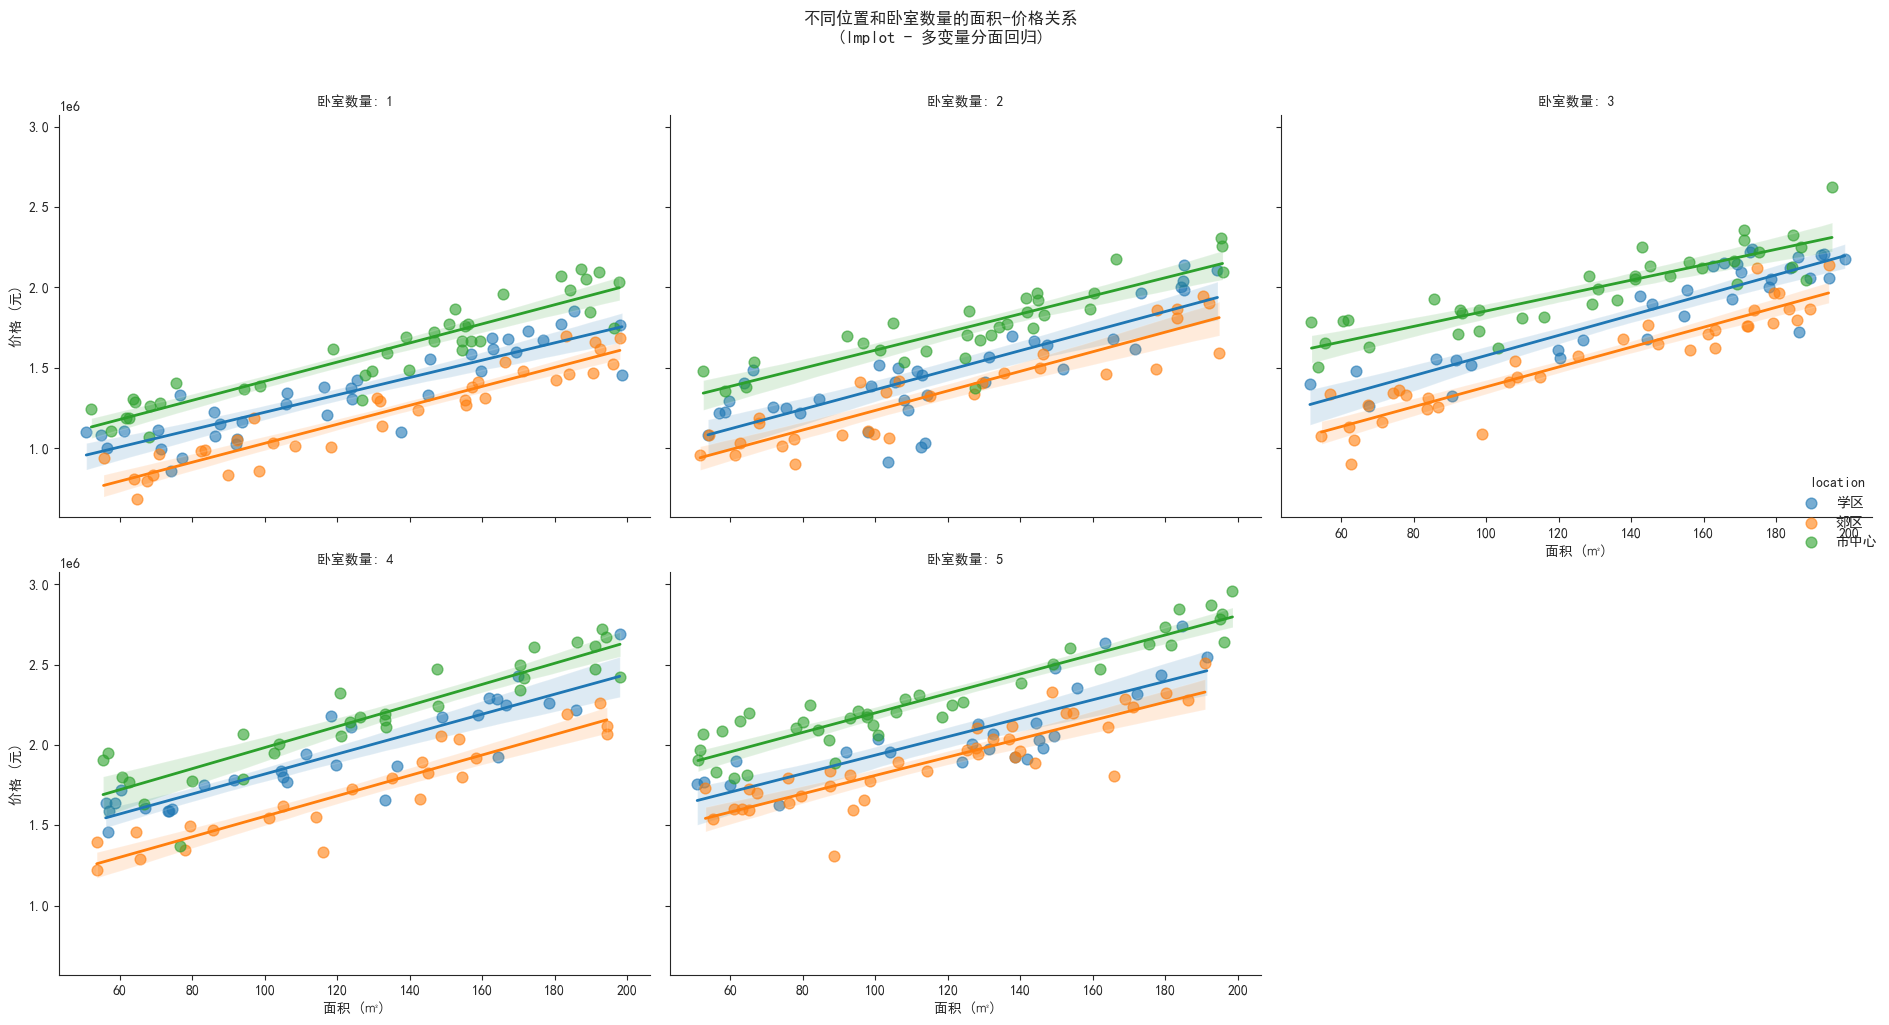

In [28]:
# 多变量回归分析 - 分面展示
g = sns.lmplot(data=house_data, x='area', y='price', 
               hue='location', col='bedrooms', col_wrap=3,
               height=5, aspect=1.2, 
               scatter_kws={'alpha':0.6, 's':60},
               line_kws={'linewidth': 2})
g.set_axis_labels('面积 (㎡)', '价格 (元)')
g.set_titles('卧室数量: {col_name}')
plt.suptitle('不同位置和卧室数量的面积-价格关系\n(lmplot - 多变量分面回归)', y=1.02)
plt.tight_layout()
plt.show()

`sns.residplot(data, x, y, lowess, scatter)`
- `data`：数据框或数组
- `x`：X 轴变量名
- `y`：Y 轴变量名
- `lowess`：是否使用局部加权回归
- `scatter`：是否显示散点

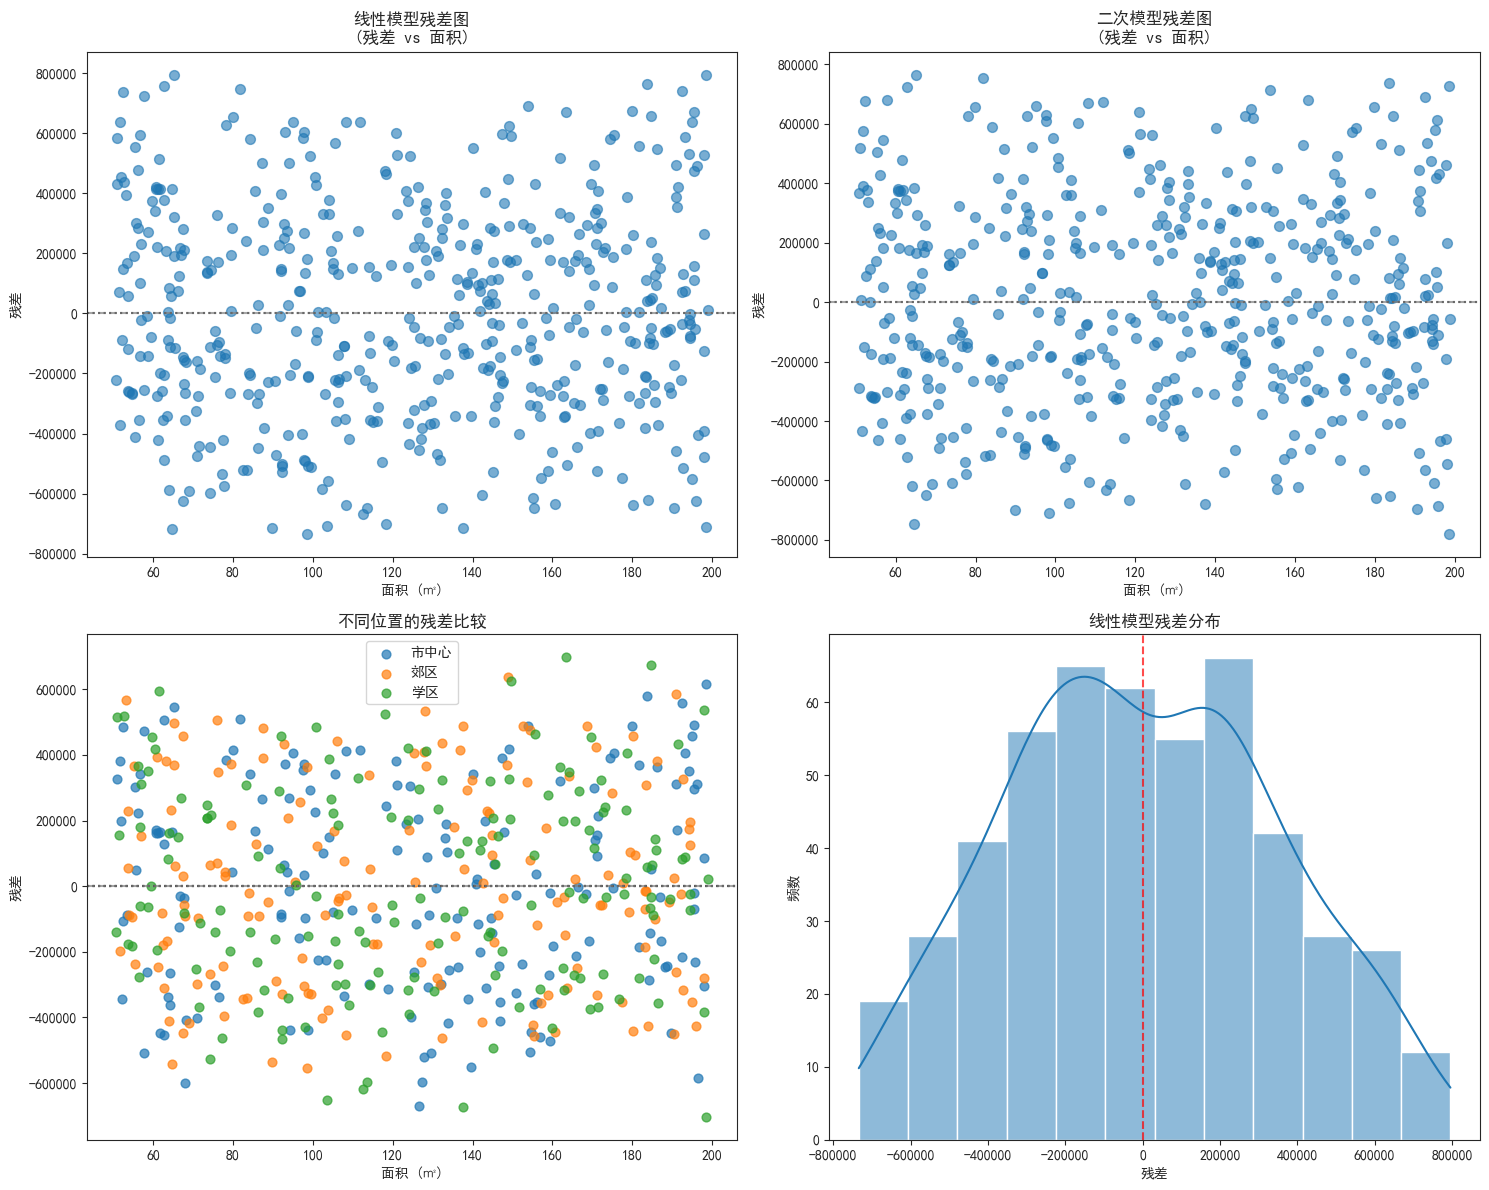

In [29]:
# 创建残差分析图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. 线性模型的残差
sns.residplot(data=house_data, x='area', y='price', 
              scatter_kws={'alpha':0.6, 's':50},
              line_kws={'color': 'red', 'linewidth': 2}, ax=axes[0,0])
axes[0,0].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[0,0].set_title('线性模型残差图\n(残差 vs 面积)')
axes[0,0].set_xlabel('面积 (㎡)')
axes[0,0].set_ylabel('残差')

# 2. 多项式模型的残差
sns.residplot(data=house_data, x='area', y='price', order=2,
              scatter_kws={'alpha':0.6, 's':50},
              line_kws={'color': 'green', 'linewidth': 2}, ax=axes[0,1])
axes[0,1].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[0,1].set_title('二次模型残差图\n(残差 vs 面积)')
axes[0,1].set_xlabel('面积 (㎡)')
axes[0,1].set_ylabel('残差')

# 3. 按位置分组的残差
for i, location in enumerate(['市中心', '郊区', '学区']):
    subset = house_data[house_data['location'] == location]
    sns.residplot(data=subset, x='area', y='price', 
                  label=location, ax=axes[1,0],
                  scatter_kws={'alpha':0.7, 's':40})
axes[1,0].axhline(y=0, color='gray', linestyle='--', alpha=0.7)
axes[1,0].set_title('不同位置的残差比较')
axes[1,0].set_xlabel('面积 (㎡)')
axes[1,0].set_ylabel('残差')
axes[1,0].legend()

# 4. 残差分布直方图
residuals_linear = house_data['price'] - LinearRegression().fit(
    house_data[['area']], house_data['price']).predict(house_data[['area']])
sns.histplot(data=residuals_linear, ax=axes[1,1], kde=True)
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].set_title('线性模型残差分布')
axes[1,1].set_xlabel('残差')
axes[1,1].set_ylabel('频数')

plt.tight_layout()
plt.show()

我们将房子面积-价格数据的回归图综合展示如下：

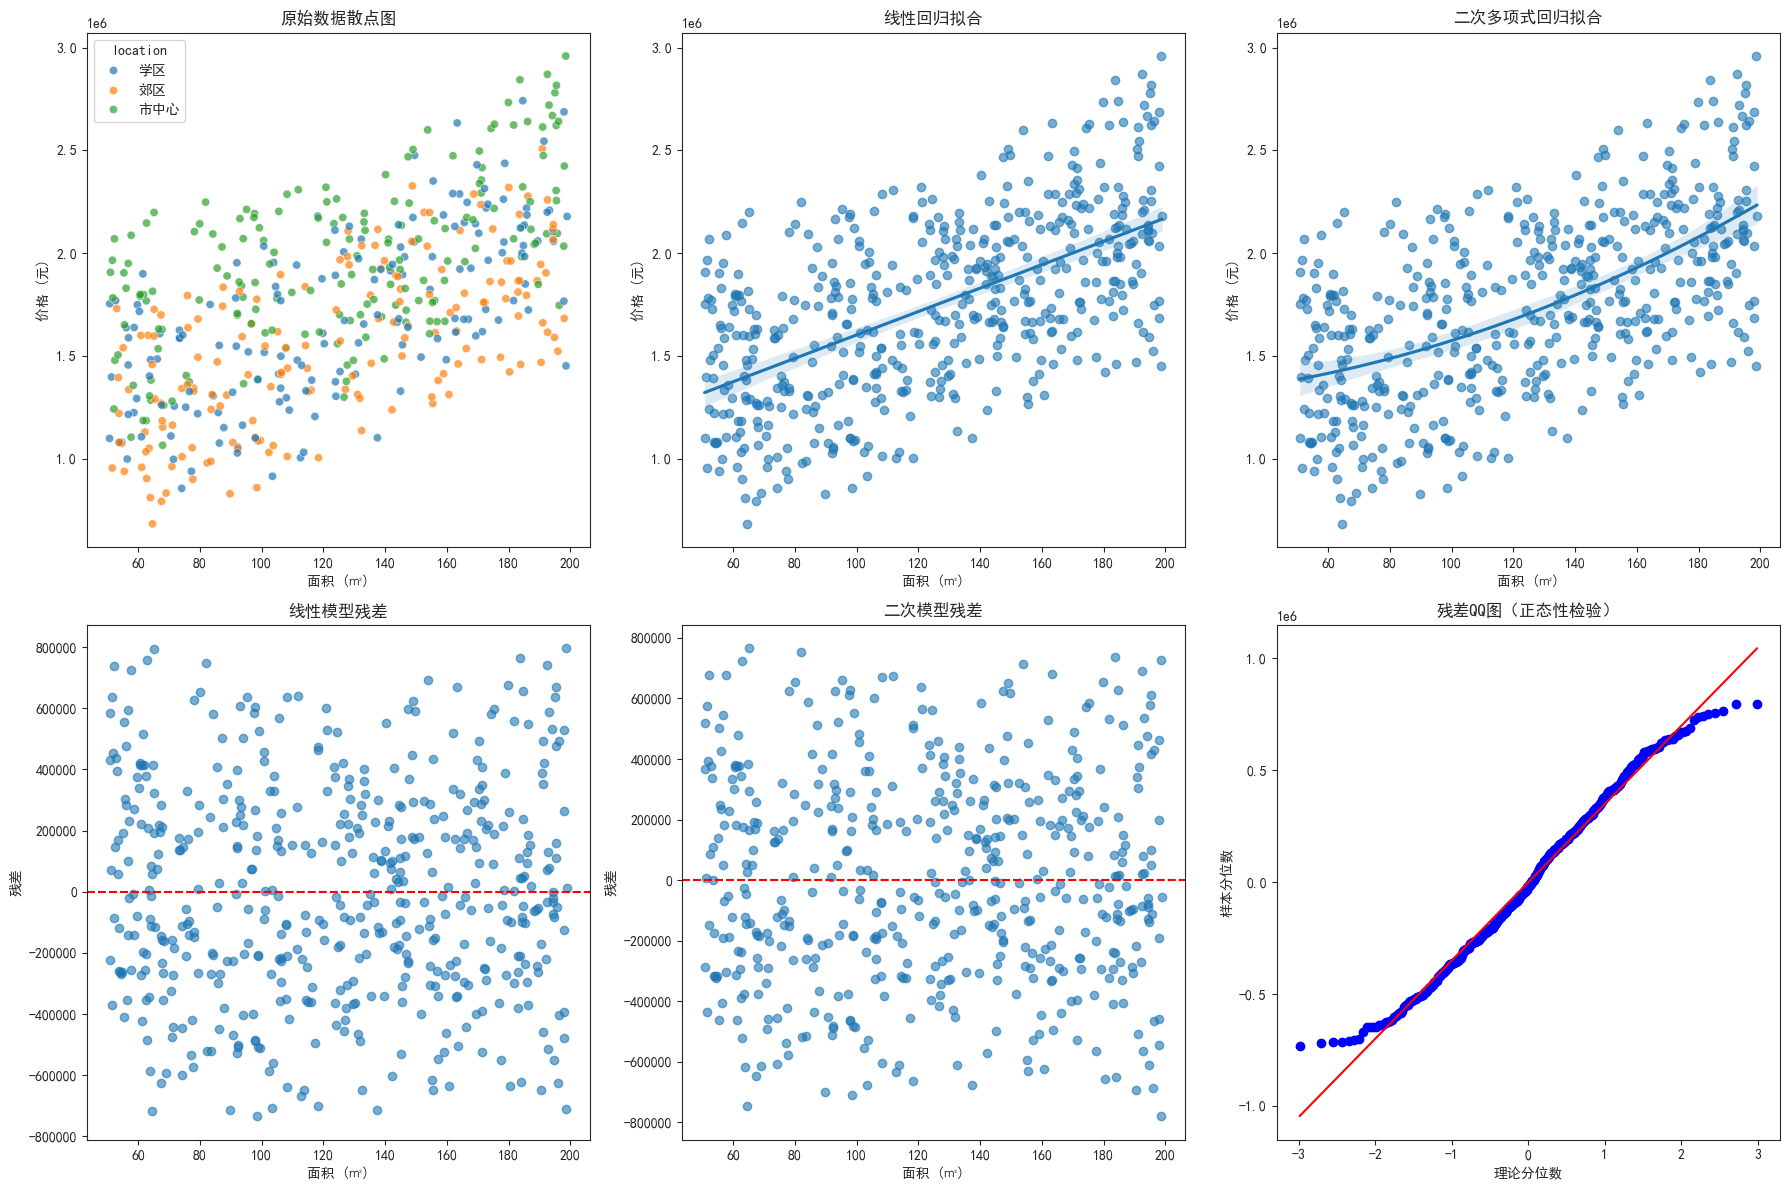

In [30]:
# 回归诊断综合展示
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 原始数据散点图
sns.scatterplot(data=house_data, x='area', y='price', 
                hue='location', ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('原始数据散点图')
axes[0,0].set_xlabel('面积 (㎡)')
axes[0,0].set_ylabel('价格 (元)')

# 2. 线性回归拟合
sns.regplot(data=house_data, x='area', y='price', 
            ax=axes[0,1], scatter_kws={'alpha':0.6})
axes[0,1].set_title('线性回归拟合')
axes[0,1].set_xlabel('面积 (㎡)')
axes[0,1].set_ylabel('价格 (元)')

# 3. 多项式回归拟合
sns.regplot(data=house_data, x='area', y='price', order=2,
            ax=axes[0,2], scatter_kws={'alpha':0.6})
axes[0,2].set_title('二次多项式回归拟合')
axes[0,2].set_xlabel('面积 (㎡)')
axes[0,2].set_ylabel('价格 (元)')

# 4. 线性模型残差
sns.residplot(data=house_data, x='area', y='price', 
              ax=axes[1,0], scatter_kws={'alpha':0.6})
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_title('线性模型残差')
axes[1,0].set_xlabel('面积 (㎡)')
axes[1,0].set_ylabel('残差')

# 5. 多项式模型残差
sns.residplot(data=house_data, x='area', y='price', order=2,
              ax=axes[1,1], scatter_kws={'alpha':0.6})
axes[1,1].axhline(y=0, color='red', linestyle='--')
axes[1,1].set_title('二次模型残差')
axes[1,1].set_xlabel('面积 (㎡)')
axes[1,1].set_ylabel('残差')

# 6. 残差QQ图（检验正态性）
from scipy import stats
residuals = house_data['price'] - LinearRegression().fit(
    house_data[['area']], house_data['price']).predict(house_data[['area']])
stats.probplot(residuals, dist="norm", plot=axes[1,2])
axes[1,2].set_title('残差QQ图（正态性检验）')
axes[1,2].set_xlabel('理论分位数')
axes[1,2].set_ylabel('样本分位数')

plt.tight_layout()
plt.show()

#### 回归图-总结表

| 函数 | 适用场景 | 关键特性 |
|------|----------|----------|
| `sns.regplot()` | 单变量回归 | 多种回归方法、置信区间 |
| `sns.lmplot()` | 多变量回归 | 分面展示、分组回归 |
| `sns.residplot()` | 模型诊断 | 残差分析、模型验证 |

**选择指南：**
- **单变量分析**：使用 `regplot`，支持线性、多项式、稳健回归
- **多变量比较**：使用 `lmplot`，支持分组和分面展示
- **模型诊断**：使用 `residplot`，检查残差是否随机分布
- **业务洞察**：结合业务背景选择合适变量，分析因果关系

**核心价值：**
1. 揭示变量间的因果关系
2. 预测目标变量的变化
3. 诊断模型假设是否成立

### 矩阵图

矩阵图用于展示变量之间的相关性或分布情况，`seaborn` 提供了多种矩阵图绘制方法，常用的有以下几种：
- 热力图（*Heatmap*）：使用 `sns.heatmap()` 函数绘制，适用于展示矩阵数据的热度分布；
- 聚类热力图（*Clustered Heatmap*）：使用 `sns.clustermap()` 函数绘制，适用于展示带有聚类信息的热力图。

先生成一些股票市场的示例数据：

In [45]:
# 创建综合数据集：股票市场数据
np.random.seed(42)
stocks = ['科技股', '金融股', '能源股', '消费股', '医药股', '工业股', '地产股', '公用事业股']
dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')

# 生成相关的股票收益率数据
n_stocks = len(stocks)
n_days = len(dates)

# 创建相关性矩阵（股票之间存在相关性）
corr_matrix = np.array([
    [1.00, 0.65, 0.30, 0.75, 0.60, 0.55, 0.40, 0.25],  # 科技股
    [0.65, 1.00, 0.45, 0.70, 0.50, 0.65, 0.75, 0.35],  # 金融股
    [0.30, 0.45, 1.00, 0.25, 0.15, 0.40, 0.30, 0.50],  # 能源股
    [0.75, 0.70, 0.25, 1.00, 0.55, 0.60, 0.45, 0.20],  # 消费股
    [0.60, 0.50, 0.15, 0.55, 1.00, 0.45, 0.35, 0.30],  # 医药股
    [0.55, 0.65, 0.40, 0.60, 0.45, 1.00, 0.70, 0.40],  # 工业股
    [0.40, 0.75, 0.30, 0.45, 0.35, 0.70, 1.00, 0.45],  # 地产股
    [0.25, 0.35, 0.50, 0.20, 0.30, 0.40, 0.45, 1.00]   # 公用事业股
])

# 生成相关的收益率数据
L = np.linalg.cholesky(corr_matrix)
uncorrelated_returns = np.random.normal(0.0005, 0.02, (n_days, n_stocks))
correlated_returns = uncorrelated_returns @ L.T

# 创建股票数据框
stock_data = pd.DataFrame(correlated_returns, columns=stocks, index=dates)
stock_data = stock_data.cumsum()  # 累积收益率

`sns.heatmap(data, annot, fmt, cmap, center, square)`
- `data`：二维数据矩阵
- `annot`：是否显示数值标注
- `fmt`：数值格式字符串
- `cmap`：调色板名称
- `center`：颜色映射中心值
- `square`：是否保持正方形

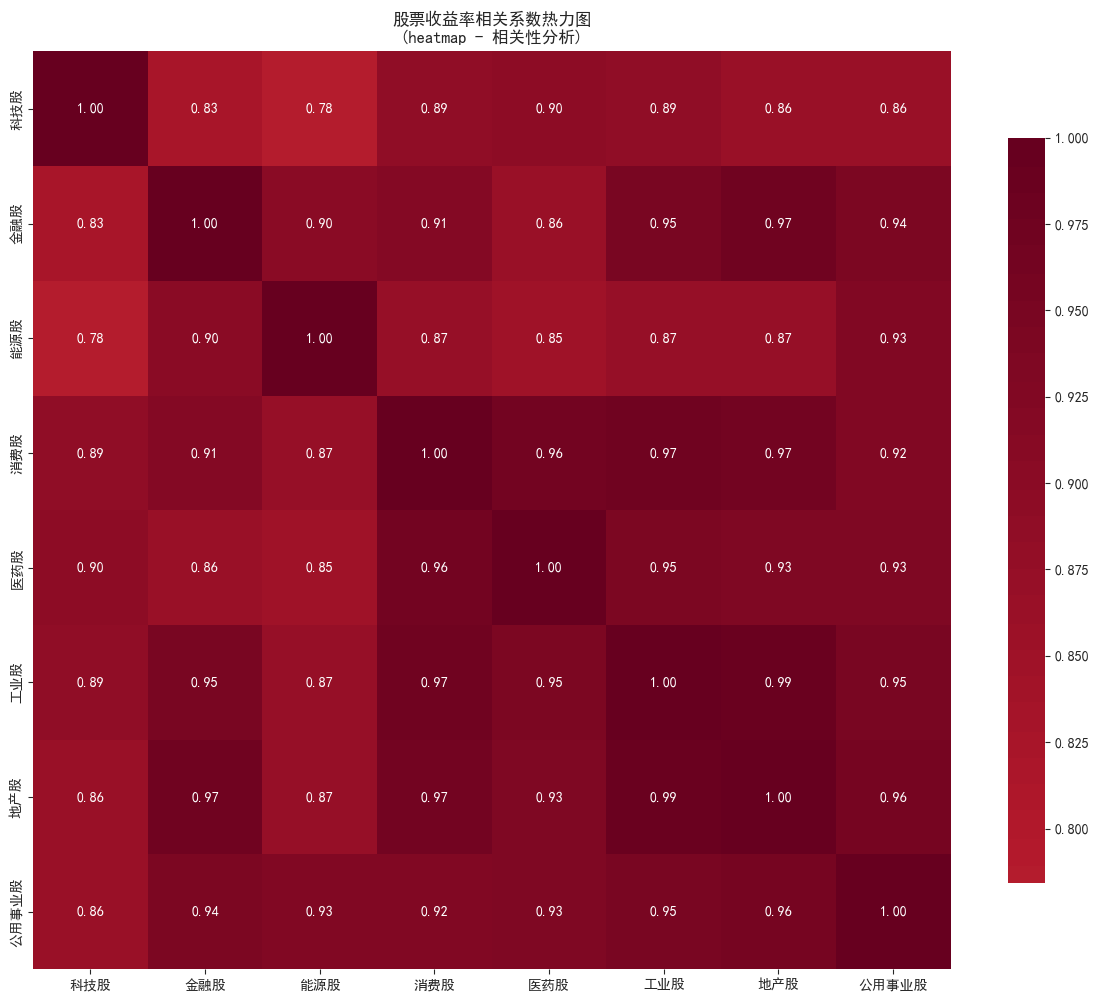

In [32]:
# 计算相关系数矩阵
correlation_matrix = stock_data.corr()

# 基础热力图
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('股票收益率相关系数热力图\n(heatmap - 相关性分析)')
plt.tight_layout()
plt.show()

`sns.clustermap(data, method, metric, cmap, standard_scale)`
- `data`：二维数据矩阵
- `method`：聚类方法，可为 `'single'`, `'complete'`, `'average'`, `'ward'`
- `metric`：距离度量，可为 `'euclidean'`, `'cityblock'`
- `cmap`：调色板名称
- `standard_scale`：标准化方式，可为 `0`, `1`

<Figure size 1200x1000 with 0 Axes>

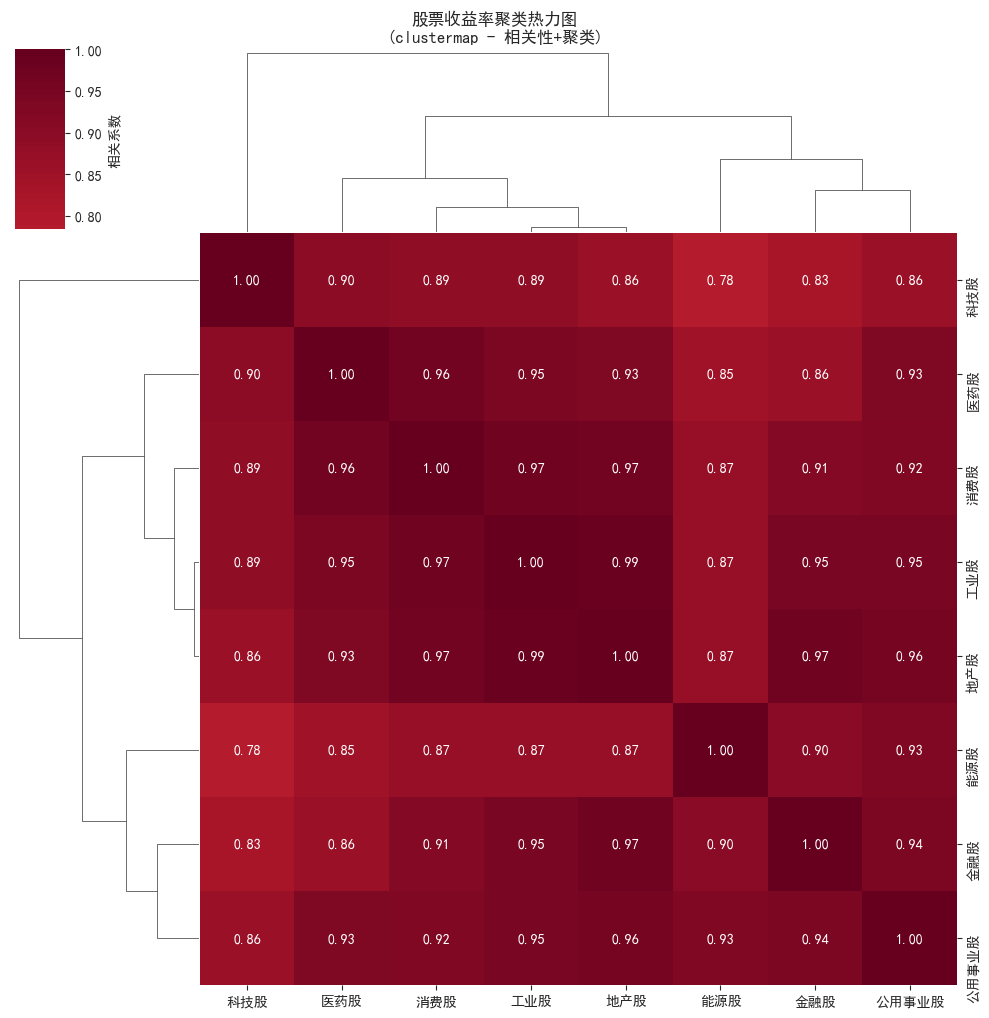

In [33]:
# 聚类热力图
plt.figure(figsize=(12, 10))
g = sns.clustermap(correlation_matrix, 
                   annot=True, fmt='.2f', cmap='RdBu_r',
                   center=0, metric='correlation',
                   cbar_kws={'label': '相关系数'})
g.fig.suptitle('股票收益率聚类热力图\n(clustermap - 相关性+聚类)', y=1.02)
plt.show()

（高级）创建跟股票收益相关的时间序列矩阵图

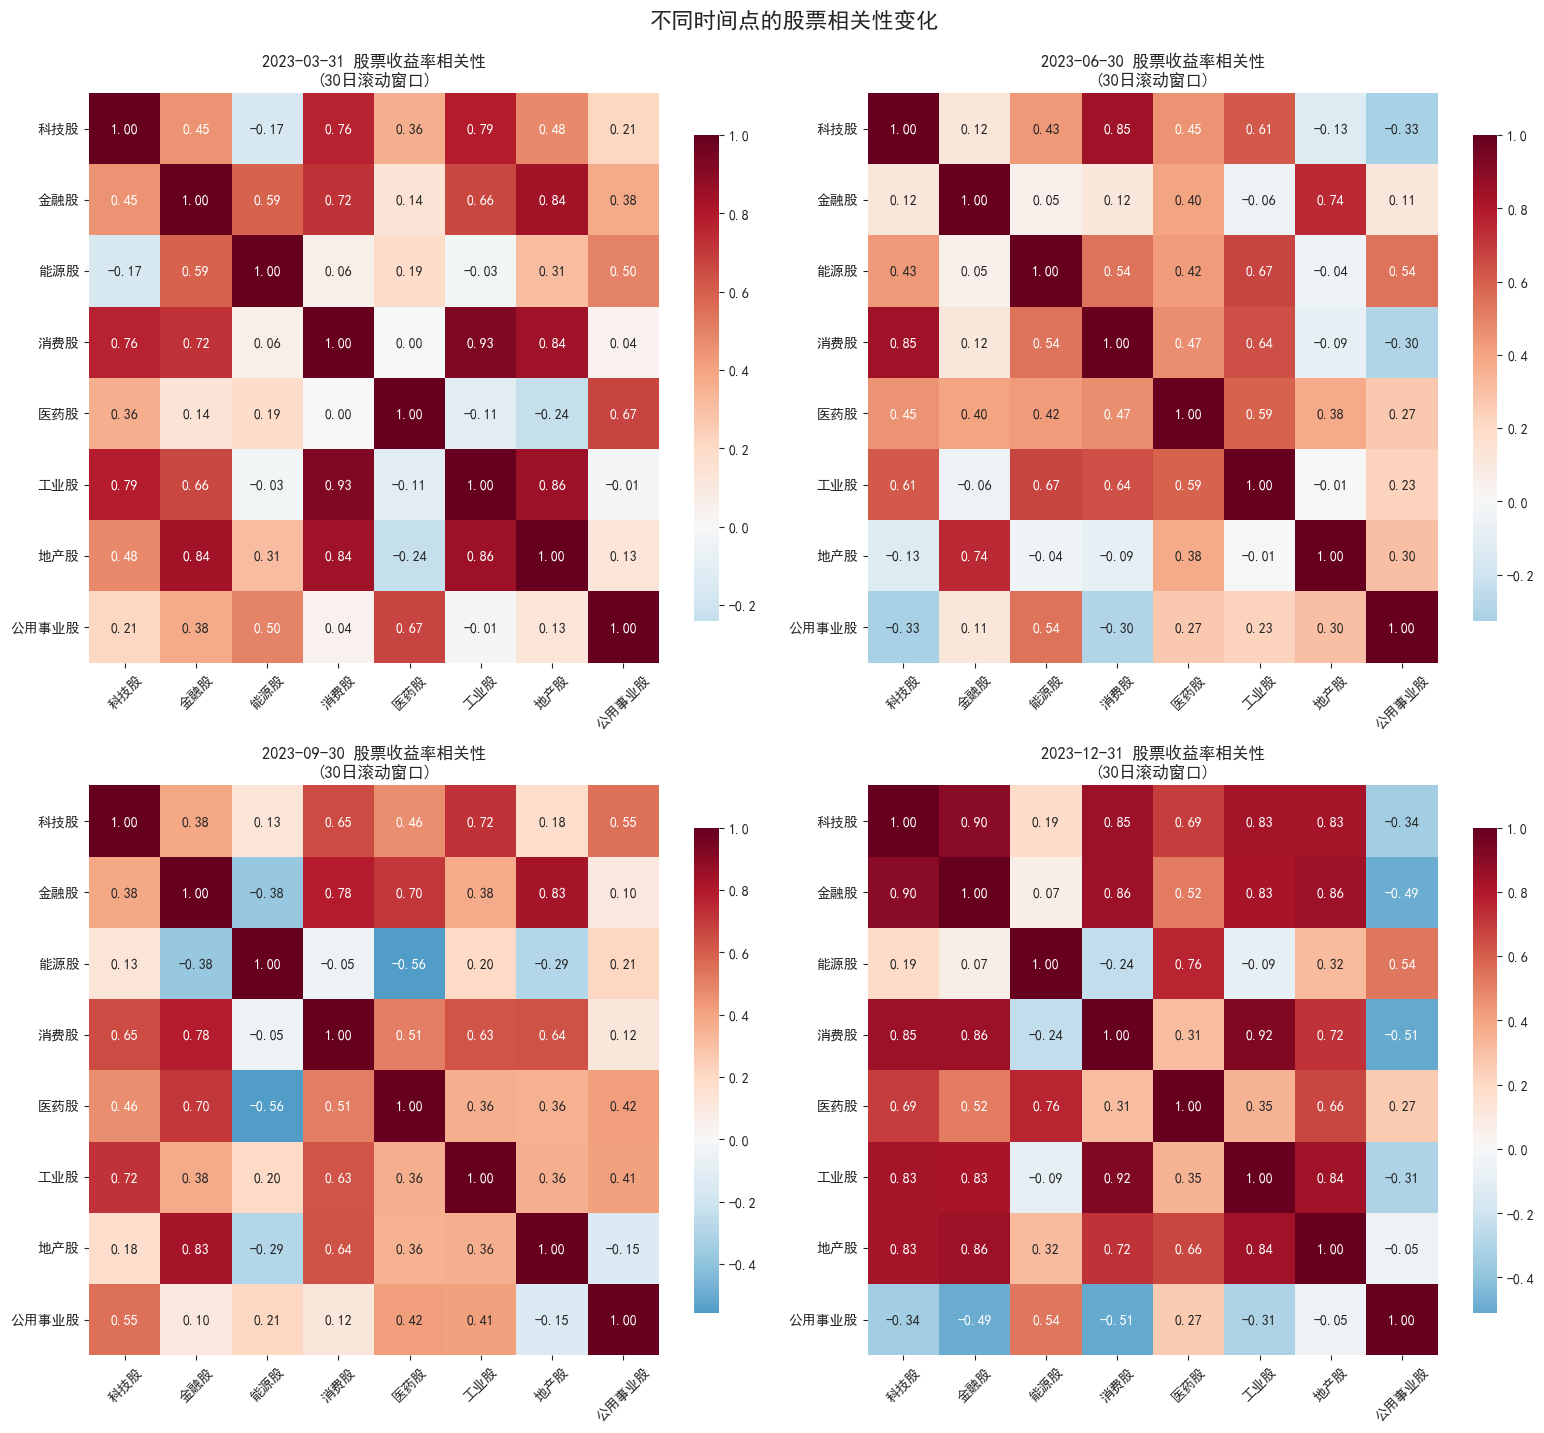

In [34]:
# 创建时间序列相关矩阵
# 计算股票收益率的滚动相关性
rolling_corr = stock_data.rolling(window=30).corr(pairwise=True)

# 选取特定时间点的相关性矩阵
selected_dates = ['2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31']
timepoint_correlations = []

for date in selected_dates:
    if date in rolling_corr.index.get_level_values(0):
        corr_matrix = rolling_corr.loc[date].values
        timepoint_correlations.append(corr_matrix)

# 创建时间点相关性热力图网格
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (date, corr_matrix) in enumerate(zip(selected_dates, timepoint_correlations)):
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, ax=axes[i],
                cbar_kws={'shrink': 0.8})
    axes[i].set_title(f'{date} 股票收益率相关性\n(30日滚动窗口)')
    axes[i].set_xticklabels(stocks, rotation=45)
    axes[i].set_yticklabels(stocks, rotation=0)

plt.tight_layout()
plt.suptitle('不同时间点的股票相关性变化', y=1.02, fontsize=16)
plt.show()

## 小结：常用方法一览

| 函数名 | 功能说明 | 作用 |
| :--- | :--- | :--- |
| **样式设置** | | |
| `set_style()` | 设置绘图样式 | 控制图表的整体美学风格，如背景色和网格线，使图表更美观或符合特定规范。 |
| `set_context()` | 设置绘图上下文 | 根据输出场景（如论文、演讲、海报）调整图表元素（字体、线宽）的大小，确保清晰度。 |
| `set_palette()` | 设置调色板 | 定义图表中使用的颜色方案，以增强可读性、区分不同类别或符合特定主题。 |
| **分布图** | | |
| `histplot()` | 绘制直方图 | 观察单个数值变量的频率分布，了解数据的集中趋势、离散程度和基本形态。 |
| `kdeplot()` | 绘制核密度估计图 | 通过平滑曲线展示数据的概率密度，用于估计其真实的、连续的分布形状。 |
| `rugplot()` | 绘制地毯图 | 在坐标轴上标记每个数据点的精确位置，常与KDE或直方图结合使用以显示原始数据分布。 |
| `displot()` | 绘制分布图（图形级） | 作为绘制分布图的统一入口，可灵活组合多种分布图并支持分面，便于全面探索数据分布。 |
| `ecdfplot()` | 绘制经验累积分布函数图 | 显示数据点的累积分布，直观地看出小于某个值的样本比例，便于比较不同分布。 |
| **关系图** | | |
| `relplot()` | 绘制关系图（图形级） | 作为绘制关系图的统一入口，可轻松创建散点图或线图，并支持按类别分面，进行多维度比较。 |
| `scatterplot()` | 绘制散点图 | 可视化两个数值变量之间的关系模式，如相关性、聚类和离群点。 |
| `lineplot()` | 绘制线图 | 特别适合展示数据随连续变量（如时间）变化的趋势，并能显示置信区间以表示不确定性。 |
| **分类图** | | |
| `catplot()` | 绘制分类图（图形级） | 作为绘制分类图的统一入口，可创建多种类型的分类图并支持分面，便于比较不同类别的数据。 |
| `stripplot()` | 绘制抖动散点图 | 以抖动方式展示每个类别的原始数据点，避免重叠，适合小数据集的分布观察。 |
| `swarmplot()` | 绘制蜂群图 | 通过算法调整数据点位置，使其完全不重叠，能清晰展示数据分布，但不适合大数据集。 |
| `boxplot()` | 绘制箱线图 | 通过五数概括法（最小值、下四分位数、中位数、上四分位数、最大值）和异常值来总结数据分布。 |
| `violinplot()` | 绘制小提琴图 | 结合箱线图和KDE图的特点，同时展示数据的分布摘要和概率密度形状，信息更丰富。 |
| `boxenplot()` | 绘制增强箱线图 | 提供比箱线图更详细的分布信息（多个分位数），特别适合大数据集的分布探索。 |
| `pointplot()` | 绘制点图 | 用点表示集中趋势，用线表示置信区间，便于精确比较不同类别间的差异，尤其关注变化趋势。 |
| `barplot()` | 绘制条形图 | 用条形的高度表示集中趋势（如均值），常用于比较不同类别的数值大小。 |
| `countplot()` | 绘制计数图 | 专门用于统计并可视化每个分类类别中出现的样本数量，相当于分类数据的直方图。 |
| **回归图** | | |
| `regplot()` | 绘制回归图 | 将散点图与线性回归模型拟合结果结合，直观展示两个变量间的线性关系及其强度。 |
| `lmplot()` | 绘制线性模型图（图形级） | 功能与`regplot`类似，但作为图形级函数，增加了按类别分面的能力，便于分组分析回归关系。 |
| `residplot()` | 绘制残差图 | 用于回归诊断，通过可视化残差（预测值与真实值之差）来检验模型的假设是否成立。 |
| **矩阵图** | | |
| `heatmap()` | 绘制热力图 | 用颜色深浅表示矩阵中数值的大小，非常适合可视化相关性矩阵、混淆矩阵等二维数据。 |
| `clustermap()` | 绘制聚类图 | 在热力图的基础上对行列进行层次聚类，并将相似的项聚集在一起，便于发现数据中的模式或群组。 |

如果希望了解更多详细信息和高级用法，可以参考 `seaborn` 的[官方文档](https://seaborn.pydata.org/)。

## 多变量可视化

**什么是多变量图？**

多变量图是一种在单一图表中同时展示和探索三个或更多变量之间关系的可视化方法。

它的核心思想是：不再孤立地看待每个变量，而是通过视觉（如颜色、大小、形状、透明度或分面）将多个变量的信息融合在一起，从而揭示它们之间复杂的相互作用、依赖关系和隐藏模式。

可以把它看作是单变量图（如直方图）和双变量图（如散点图）的延伸和升级。

**多变量图的好处**

- 揭示隐藏关系：可以直观地看到不同类别在两个数值维度上的分布差异。
- 提高比较效率：将所有组的数据放在同一坐标系下，可以非常方便地进行直接比较。我们无需为每个类别单独创建图表，就能快速判断哪个类群的密度更高、分布更集中或与其他类群的重叠程度。
- 识别数据结构与异常：有助于识别数据中的聚类、趋势和潜在的异常值。
- 增强信息传达：在报告或演示中，一张好的多变量图比多张单变量图更具说服力，能用更简洁的方式传达更丰富的信息。

### 二维核密度估计图

一维核密度估计图基于一维数据，二维核密度估计图（KDE）则基于二维数据，并用颜色区分变量。

注意，我们只需要传给 `sns.kdeplot()` 两维数据即可，`seaborn` 会自动计算二维核密度估计并绘制等高线图。

下面我们生成一组身高-体重的数据：

In [35]:
np.random.seed(42)
n_samples = 1000

# 创建单峰分布数据
height_weight = pd.DataFrame({
    'height': np.random.normal(170, 8, n_samples),
    'weight': 50 + 0.7 * (np.random.normal(170, 8, n_samples) - 170) + np.random.normal(0, 5, n_samples),
    'gender': np.random.choice(['男', '女'], n_samples)
})

# 添加性别差异
male_mask = height_weight['gender'] == '男'
height_weight.loc[male_mask, 'height'] += 5
height_weight.loc[male_mask, 'weight'] += 10

再绘制四种不同模式下的身高-体重二维KDE图

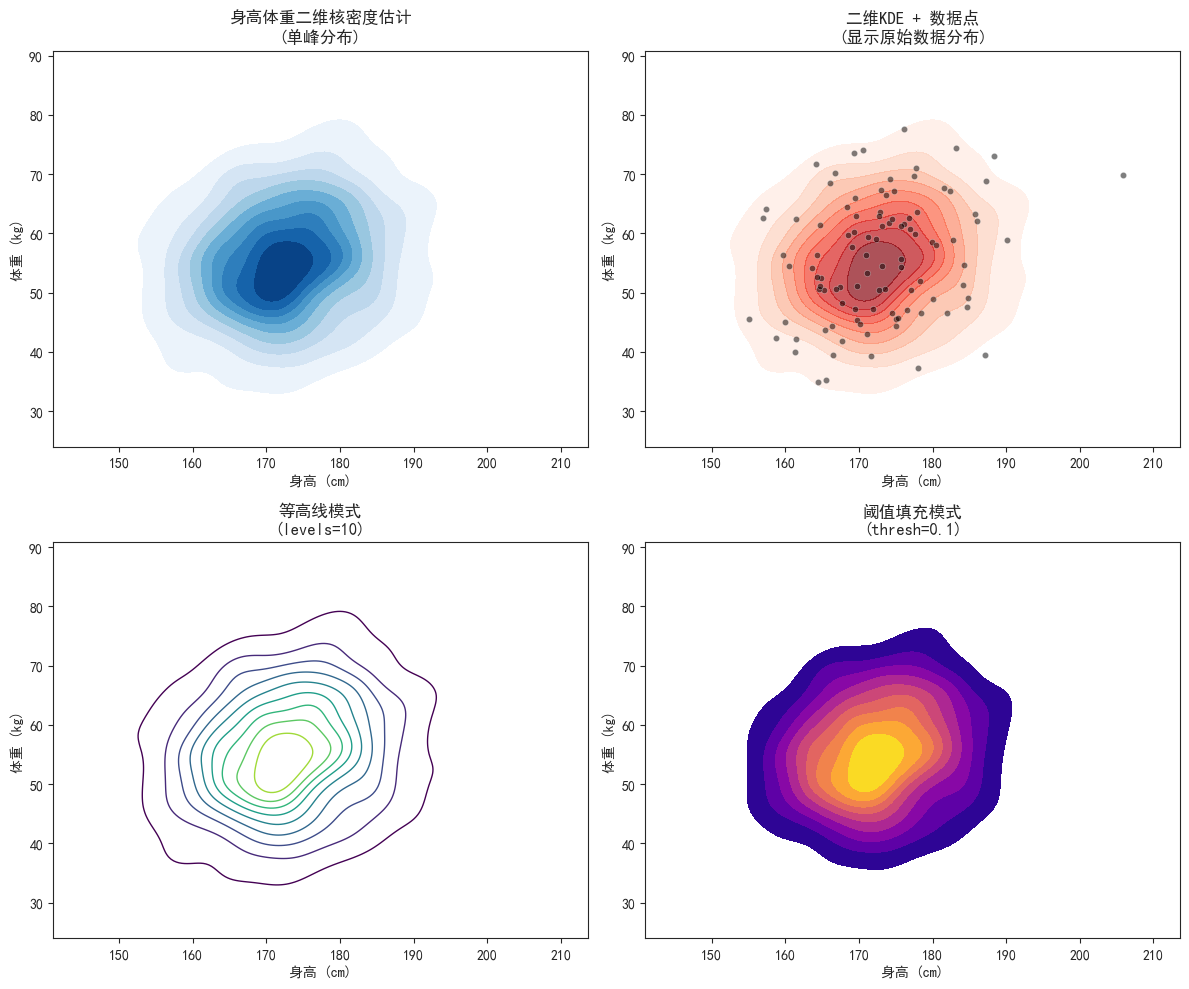

In [36]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.kdeplot(data=height_weight, x='height', y='weight', fill=True, cmap='Blues')
plt.title('身高体重二维核密度估计\n(单峰分布)')
plt.xlabel('身高 (cm)')
plt.ylabel('体重 (kg)')

plt.subplot(2, 2, 2)
sns.kdeplot(data=height_weight, x='height', y='weight', fill=True, cmap='Reds', alpha=0.7)
sns.scatterplot(data=height_weight.sample(100), x='height', y='weight', alpha=0.5, color='black', s=20)
plt.title('二维KDE + 数据点\n(显示原始数据分布)')
plt.xlabel('身高 (cm)')
plt.ylabel('体重 (kg)')

plt.subplot(2, 2, 3)
sns.kdeplot(data=height_weight, x='height', y='weight', levels=10, cmap='viridis', linewidths=1)
plt.title('等高线模式\n(levels=10)')
plt.xlabel('身高 (cm)')
plt.ylabel('体重 (kg)')

plt.subplot(2, 2, 4)
sns.kdeplot(data=height_weight, x='height', y='weight', fill=True, thresh=0.1, cmap='plasma')
plt.title('阈值填充模式\n(thresh=0.1)')
plt.xlabel('身高 (cm)')
plt.ylabel('体重 (kg)')

plt.tight_layout()
plt.show()

### 联合分布图

**什么是联合分布图？**

联合分布图 是一种专门用于同时探索两个及两个以上数值变量之间关系以及每个变量自身分布的可视化工具。

**好处在哪？**

联合分布图的主要作用是将双变量分析和单变量分析无缝地结合起来，方便我们：
- 同时观察关系与分布
- 快速识别异常值：异常值在中心的散点图中会显得格格不入。
- 比较不同类别的模式
- 理解数据密度

二维：首先生成房屋面积-价格的一组数据

In [37]:
np.random.seed(42)
n_samples = 1000

house_data = pd.DataFrame({
    'area': np.random.normal(120, 40, n_samples),
    'price': 500000 + 4000 * np.random.normal(120, 40, n_samples) + np.random.normal(0, 100000, n_samples),
    'location': np.random.choice(['市中心', '郊区', '学区房'], n_samples)
})

# 添加位置效应
house_data.loc[house_data['location'] == '市中心', 'price'] += 300000
house_data.loc[house_data['location'] == '学区房', 'price'] += 200000
house_data.loc[house_data['location'] == '郊区', 'price'] -= 100000

再使用`jointplot`生成房屋面积-价格的联合分布图

<Figure size 1200x1000 with 0 Axes>

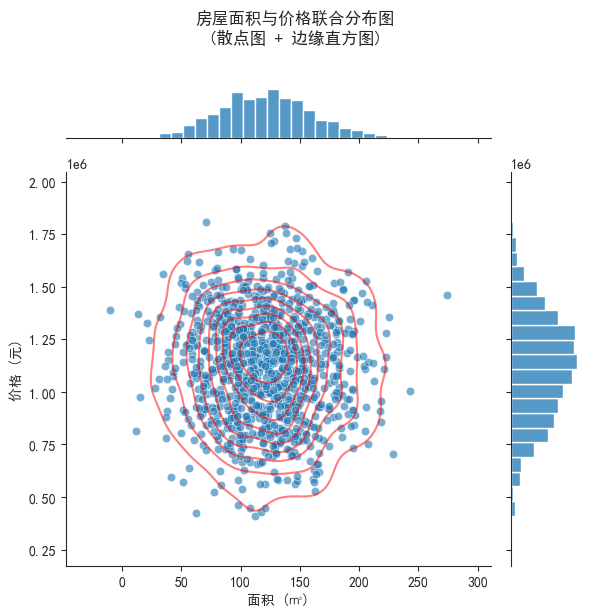

In [38]:
plt.figure(figsize=(12, 10))
g = sns.jointplot(data=house_data, x='area', y='price', 
                  kind='scatter', alpha=0.6)
g.plot_joint(sns.kdeplot, color='red', alpha=0.5)
g.set_axis_labels('面积 (㎡)', '价格 (元)')
plt.suptitle('房屋面积与价格联合分布图\n(散点图 + 边缘直方图)', y=1.02)
plt.tight_layout()
plt.show()

三维：对三类不同的产品（电子产品、服装、美妆）生成一组消费数据

In [39]:
np.random.seed(42)
user_behavior = pd.DataFrame({
    'time_spent': np.concatenate([
        np.random.normal(8, 2, 300),   # 电子产品
        np.random.normal(5, 1.5, 300), # 服装
        np.random.normal(12, 3, 300)   # 美妆
    ]),
    'purchase_amount': np.concatenate([
        np.random.normal(2000, 500, 300),  # 电子产品
        np.random.normal(300, 100, 300),   # 服装
        np.random.normal(500, 150, 300)    # 美妆
    ]),
    'category': ['电子产品'] * 300 + ['服装'] * 300 + ['美妆'] * 300
})


再使用`jointplot`生成三类不同产品的消费行为的联合分布图

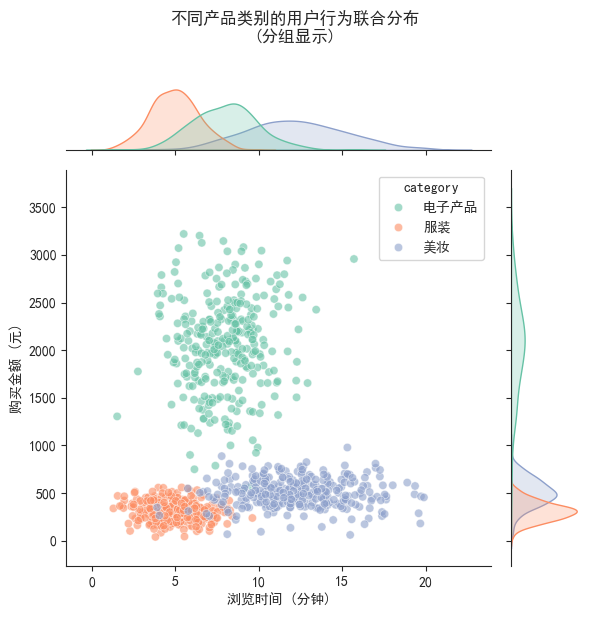

In [40]:
# 分组联合分布图
g = sns.jointplot(data=user_behavior, x='time_spent', y='purchase_amount',
                  hue='category', alpha=0.6, palette='Set2')
g.set_axis_labels('浏览时间 (分钟)', '购买金额 (元)')
plt.suptitle('不同产品类别的用户行为联合分布\n(分组显示)', y=1.02)
plt.tight_layout()
plt.show()

### 配对图

**什么是配对图？**

配对图是一个网格状的图表，它能让你在一个视图中快速浏览整个数据集的全貌。

配对图相当于一个数据集的“仪表盘”：

- 对角线上的图：展示每个单个变量的分布情况（直方图或密度图）。
- 非对角线上的图：展示两个变量之间的关系（散点图或回归图）。

**配对图有什么作用？**

通过这一个图，你就能快速掌握整个数据集的全貌，包括变量自身的分布特征和变量之间的相互关系。并且有助于发现数据聚类和可分性。

下面针对前面的花卉数据集，使用 `sns.pairplot()` 创建配对图：

为了减轻学习者的负担，我们沿用了之前的房屋数据

In [41]:
np.random.seed(42)
house_data = pd.DataFrame({
    '面积': np.random.normal(120, 40, 300),
    '价格': 500000 + 4000 * np.random.normal(120, 40, 300) + np.random.normal(0, 100000, 300),
    '卧室数量': np.random.choice([1, 2, 3, 4, 5], 300),
    '房龄': np.random.exponential(10, 300),
    '位置评分': np.random.uniform(3, 5, 300)
})

# 添加相关性
house_data['价格'] = house_data['价格'] + 50000 * (house_data['卧室数量'] - 2)
house_data['价格'] = house_data['价格'] - 10000 * house_data['房龄']
house_data['位置评分'] = house_data['位置评分'] + 0.1 * (house_data['价格'] - house_data['价格'].mean()) / house_data['价格'].std()

# 创建价格分段变量（修复缺失的变量）
house_data['价格分段'] = pd.cut(house_data['价格'], 
                               bins=[0, 600000, 800000, 1000000, float('inf')],
                               labels=['低价', '中价', '高价', '豪华'])

按照价格分段，绘制配对图

<Figure size 1200x1000 with 0 Axes>

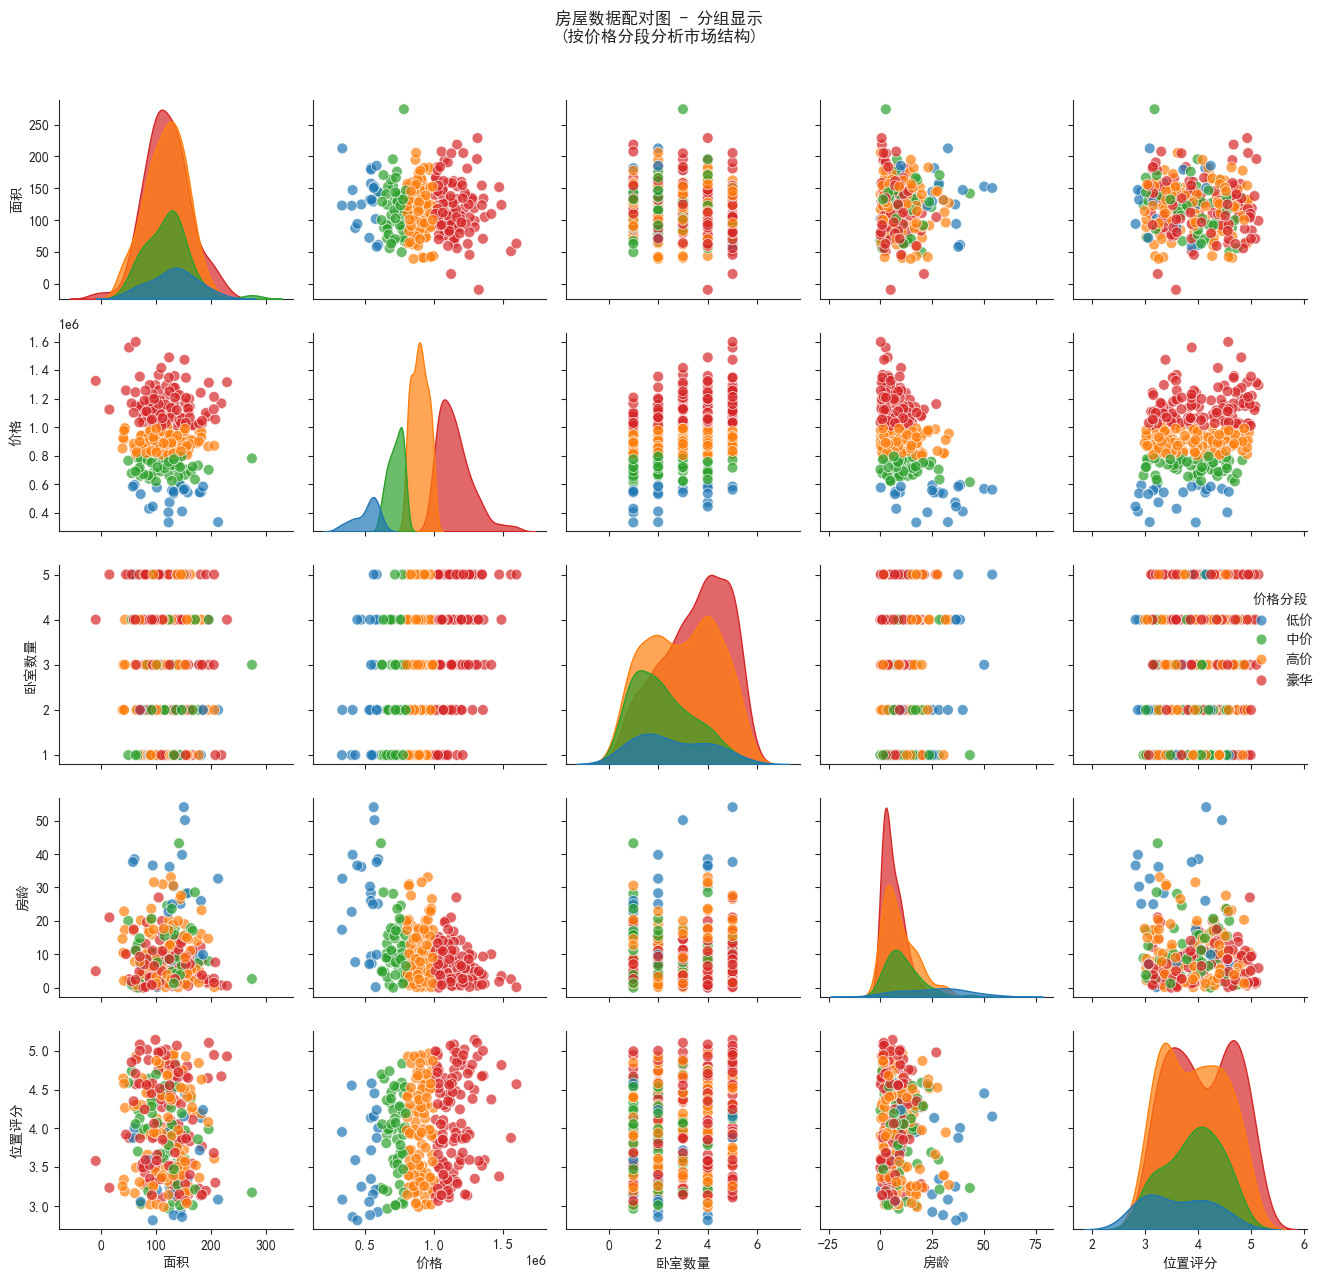

房屋数据基本信息：
数据形状: (300, 6)
价格分段分布:
价格分段
低价     21
中价     51
高价    109
豪华    119
Name: count, dtype: int64

各变量描述性统计:
               面积            价格        卧室数量          房龄        位置评分
count  300.000000  3.000000e+02  300.000000  300.000000  300.000000
mean   119.778058  9.403753e+05    3.026667    9.573907    3.966906
std     39.367748  2.181051e+05    1.394910    9.133721    0.598748
min     -9.650694  3.326267e+05    1.000000    0.012374    2.818215
25%     92.670162  8.064334e+05    2.000000    2.906119    3.438970
50%    122.368779  9.387084e+05    3.000000    7.370618    3.948269
75%    145.066309  1.088329e+06    4.000000   13.134606    4.485874
max    274.109260  1.597571e+06    5.000000   53.993519    5.138864


In [42]:
plt.figure(figsize=(12, 10))

# 创建更有意义的颜色映射
price_palette = {
    '低价': '#1f77b4', 
    '中价': '#2ca02c',
    '高价': '#ff7f0e',  
    '豪华': '#d62728'    
}

g = sns.pairplot(house_data, hue='价格分段', palette=price_palette,
                 plot_kws={'alpha': 0.7, 's': 60},
                 diag_kws={'alpha': 0.7})
plt.suptitle('房屋数据配对图 - 分组显示\n(按价格分段分析市场结构)', y=1.02)
plt.tight_layout()
plt.show()

# 显示数据基本信息
print("房屋数据基本信息：")
print(f"数据形状: {house_data.shape}")
print(f"价格分段分布:")
print(house_data['价格分段'].value_counts().sort_index())
print(f"\n各变量描述性统计:")
print(house_data[['面积', '价格', '卧室数量', '房龄', '位置评分']].describe())

### 分面绘图

**什么是分面绘图？**

分面绘图将一个大数据集根据一个或多个分类变量的值，“切片”成多个子集，然后为每个子集绘制一个独立的图表，最后将这些小图表排列成一个网格。

**有什么作用？**

分面绘图是解决“图表过于复杂”问题的利器，其主要作用如下：

- 避免视觉混乱和数据重叠： 分面绘图通过将数据分离开来，从根本上解决了重叠问题，让每个子图都干净、易读。

- 便于进行“同类比较”： 网格化的布局让我们的眼睛可以非常轻松地进行横向和纵向的比较。

- 揭示“条件关系”： 帮助解决“两个变量之间的关系，是否会受到第三个变量的影响？”的问题。

下面的代码展示了 `replplot()` 函数的分面绘图功能：

示例：房屋数据分面绘图（之前出现过的数据）

房屋面积分面图 - 按区域比较


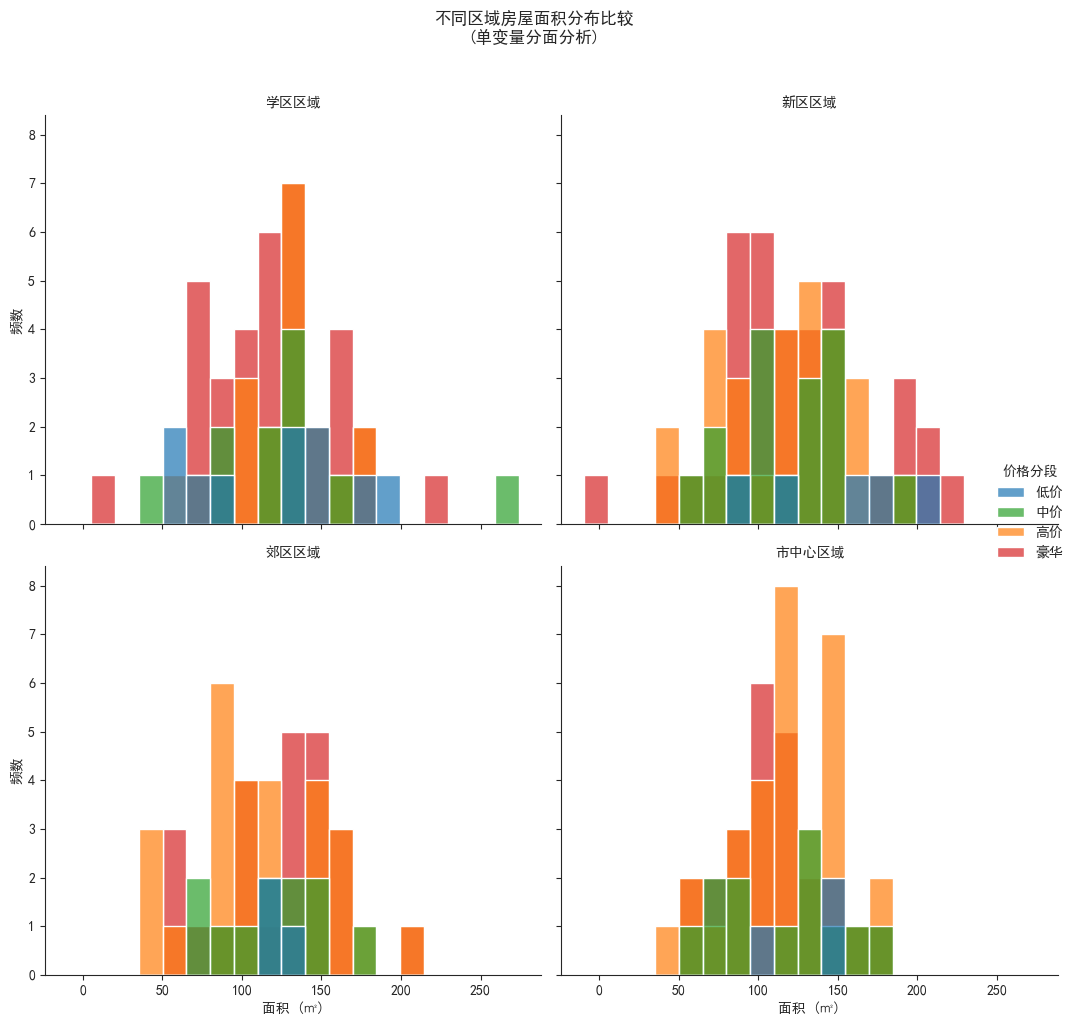

In [43]:
np.random.seed(42)
house_data = pd.DataFrame({
    '面积': np.random.normal(120, 40, 300),
    '价格': 500000 + 4000 * np.random.normal(120, 40, 300) + np.random.normal(0, 100000, 300),
    '卧室数量': np.random.choice([1, 2, 3, 4, 5], 300),
    '房龄': np.random.exponential(10, 300),
    '位置评分': np.random.uniform(3, 5, 300),
    '区域': np.random.choice(['市中心', '学区', '郊区', '新区'], 300)
})

# 添加相关性
house_data['价格'] = house_data['价格'] + 50000 * (house_data['卧室数量'] - 2)
house_data['价格'] = house_data['价格'] - 10000 * house_data['房龄']
house_data['位置评分'] = house_data['位置评分'] + 0.1 * (house_data['价格'] - house_data['价格'].mean()) / house_data['价格'].std()

# 创建价格分段
house_data['价格分段'] = pd.cut(house_data['价格'], 
                               bins=[0, 600000, 800000, 1000000, float('inf')],
                               labels=['低价', '中价', '高价', '豪华'])

# 单变量分面：不同区域的面积分布
print("房屋面积分面图 - 按区域比较")
g = sns.displot(data=house_data, x='面积', hue='价格分段', col='区域', 
                col_wrap=2, kind='hist', alpha=0.7, 
                palette=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
g.set_axis_labels('面积 (㎡)', '频数')
g.set_titles('{col_name}区域')
plt.suptitle('不同区域房屋面积分布比较\n(单变量分面分析)', y=1.02)
plt.tight_layout()
plt.show()

## 置信区间和误差条

置信区间（*confidence interval*，CI）是一种统计学概念，用于表示估计值的不确定性范围。它通过一个区间来表达我们对某个参数（如均值、比例等）的估计值的置信程度。置信区间通常以百分比表示，如 95% 置信区间表示我们有 95% 的信心认为该区间包含了真实的参数值。

误差条（*error bar*）是一种图形元素，通常用于表示数据点的变异性或不确定性。它们以线段的形式延伸出数据点，显示数据点的可能范围。误差条可以表示标准误差、标准偏差或置信区间等。

`seaborn` 中的许多绘图函数（如 `lineplot()`、`barplot()`、`pointplot()` 等）都支持自动计算和显示置信区间和误差条。通过设置参数 `ci` 和 `capsize`，我们可以控制置信区间的大小和误差条的样式。

- 设置 `ci=95` 即计算出该均值的 95% 置信区间；
- 设置 `capsize=0.1` 为置信区间的误差线添加了“小帽子”，让区间的端点更清晰，视觉效果更好。

下面的代码展示了如何在 `lineplot()` 中使用置信区间和误差条：

房屋价格置信区间 - 区域比较


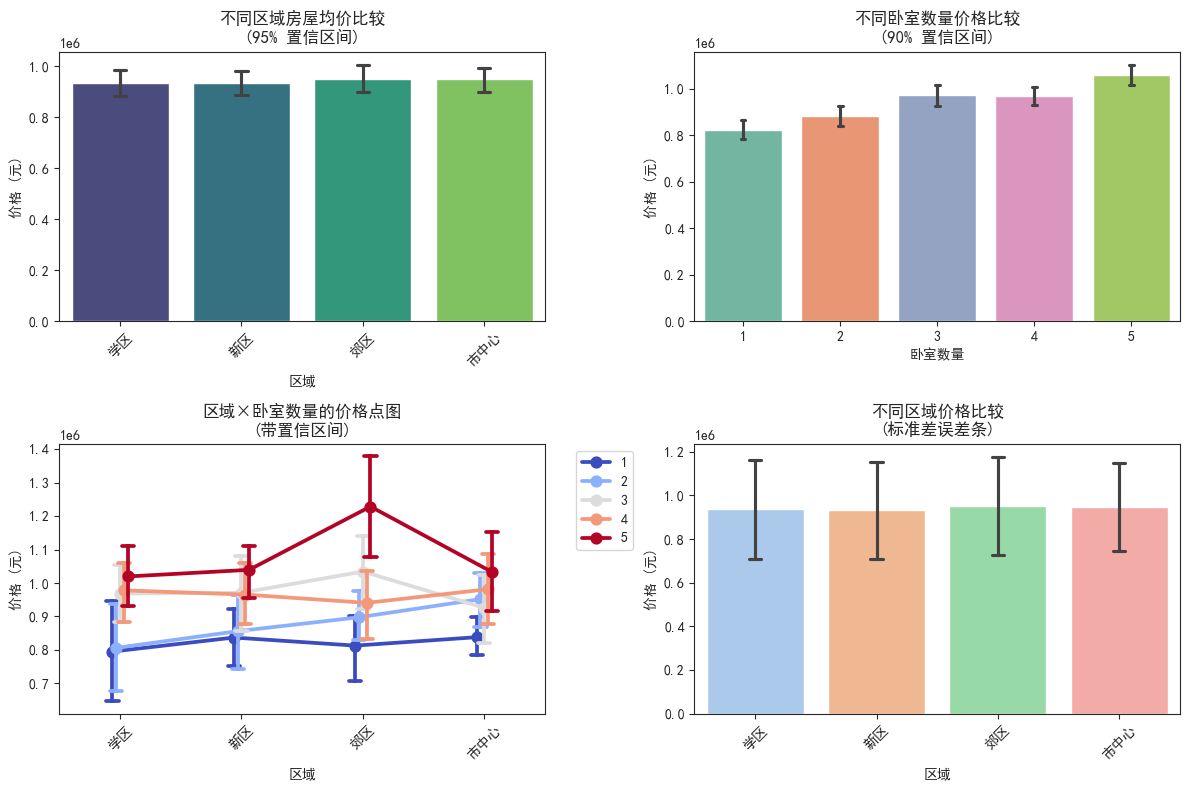

In [44]:
# 使用之前生成的房屋数据
np.random.seed(42)
house_data = pd.DataFrame({
    '面积': np.random.normal(120, 40, 300),
    '价格': 500000 + 4000 * np.random.normal(120, 40, 300) + np.random.normal(0, 100000, 300),
    '卧室数量': np.random.choice([1, 2, 3, 4, 5], 300),
    '房龄': np.random.exponential(10, 300),
    '位置评分': np.random.uniform(3, 5, 300),
    '区域': np.random.choice(['市中心', '学区', '郊区', '新区'], 300)
})

# 添加相关性
house_data['价格'] = house_data['价格'] + 50000 * (house_data['卧室数量'] - 2)
house_data['价格'] = house_data['价格'] - 10000 * house_data['房龄']

# 条形图 + 置信区间：不同区域的均价比较
print("房屋价格置信区间 - 区域比较")
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.barplot(data=house_data, x='区域', y='价格', ci=95, capsize=0.1, palette='viridis')
plt.title('不同区域房屋均价比较\n(95% 置信区间)')
plt.xticks(rotation=45)
plt.ylabel('价格 (元)')

plt.subplot(2, 2, 2)
sns.barplot(data=house_data, x='卧室数量', y='价格', ci=90, capsize=0.05, palette='Set2')
plt.title('不同卧室数量价格比较\n(90% 置信区间)')
plt.ylabel('价格 (元)')

plt.subplot(2, 2, 3)
sns.pointplot(data=house_data, x='区域', y='价格', hue='卧室数量', 
              ci=95, capsize=0.1, dodge=True, palette='coolwarm')
plt.title('区域×卧室数量的价格点图\n(带置信区间)')
plt.xticks(rotation=45)
plt.ylabel('价格 (元)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(2, 2, 4)
sns.barplot(data=house_data, x='区域', y='价格', ci='sd', capsize=0.1, palette='pastel')
plt.title('不同区域价格比较\n(标准差误差条)')
plt.xticks(rotation=45)
plt.ylabel('价格 (元)')

plt.tight_layout()
plt.show()

## 小结
seaborn的学习到此暂告一段落，希望对大家有所帮助。